<a href="https://colab.research.google.com/github/CodeHunterOfficial/ArabovMKDeep/blob/main/ADPs/Lecture_8/%D0%9B%D0%B5%D0%BA%D1%86%D0%B8%D1%8F_8_%D0%9B%D0%BE%D0%BA%D0%B0%D0%BB%D1%8C%D0%BD%D1%8B%D0%B5_LLM_%D0%B8_%D0%BF%D1%80%D0%B8%D0%B2%D0%B0%D1%82%D0%BD%D0%BE%D1%81%D1%82%D1%8C_%D0%B4%D0%B0%D0%BD%D0%BD%D1%8B%D1%85.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лекция №8: Локальные LLM и приватность данных


## 1. ВВЕДЕНИЕ

### 1.1. От облачных моделей к локальным: почему это важно для психолога

В Лекции 7 мы научились создавать веб-приложения, которые использовали облачные модели через Hugging Face Inference API. Это было удобно и быстро — не нужно было загружать модели на свой компьютер.

**Но в психологической практике есть критическое ограничение: данные пациентов нельзя отправлять на сторонние серверы.**

Любая система, работающая с естественным языком, почти неизбежно попадает под действие 152‑ФЗ: пользователи всё равно вводят ФИО, телефоны, e‑mail и другие идентифицирующие данные, даже если на экране написано «не вводите персональные данные». Юридически это означает, что вы как оператор обязаны обеспечить защиту этих данных.

**Интуитивная аналогия из психотерапии:**

> Представьте, что вы ведёте приём и записываете всё, что говорит пациент, на диктофон. Но вместо того чтобы хранить записи в сейфе в своём кабинете, вы отправляете их в неизвестную компанию «для анализа». Нарушена ли конфиденциальность? Безусловно. Именно это происходит, когда вы отправляете текст пациента в облачный ChatGPT или аналогичный сервис.

**Проблема облачных сервисов:**

- Данные передаются третьим лицам.
- Нет гарантии, что они не используются для обучения моделей.
- Нарушается 152-ФЗ «О персональных данных» — данные не покидают территорию РФ без согласия.

**Решение: локальные LLM** — модели, которые работают на вашем компьютере. Данные **никогда не покидают ваше устройство**. Всё происходит офлайн.

**Что мы узнаем сегодня:**

- Какие преимущества даёт локальный запуск LLM для психолога.
- Как установить и настроить **Ollama** — платформу для запуска локальных моделей.
- Как подключить локальные модели к **VS Code** для работы с текстами.
- Какие модели доступны: **Qwen, DeepSeek, Llama, Mistral** — сравнение по размеру и качеству.
- Как настроить **системные промпты** для работы в психологическом контексте.

**Ключевая мысль:** локальные LLM позволяют использовать мощь ИИ, **сохраняя полный контроль над данными**. Это единственный этически приемлемый способ применения генеративного ИИ в клинической психологии.

**Связь с предыдущими лекциями:**

- Лекция 7 — мы создавали веб-приложения. Сегодня мы заменим облачные API на локальные модели.
- Лекция 5 — мы говорили о BERT и GPT. Сегодня мы увидим, как запускать их на своём компьютере.

---

### 1.2. Актуальность для клинической психологии

Согласно исследованиям [7], количество психологов, использующих ИИ-инструменты в работе, продолжает расти. Однако большинство из них используют облачные сервисы, не осознавая рисков для конфиденциальности пациентов.

**Ситуация в России:**

- 152-ФЗ «О персональных данных» требует, чтобы обработка персональных данных осуществлялась с соблюдением принципов законности и конфиденциальности [2].
- С 1 сентября 2025 года вступили в силу поправки к 152-ФЗ, касающиеся взаимодействия персональных данных с цифровыми сервисами и искусственным интеллектом.
- Согласно ч. 4 ст. 21 152-ФЗ, персональные данные должны обрабатываться в течение 30 дней после обработки запроса.

**Вывод:** если вы отправляете текст пациента в облачный API — вы **передаёте** персональные данные третьему лицу. Это нарушает 152-ФЗ без явного согласия пациента и договора с оператором. Локальный запуск **полностью исключает** эту проблему.

---

## 2. ПРЕИМУЩЕСТВА ЛОКАЛЬНОГО ЗАПУСКА

### 2.1. Приватность и безопасность — главный аргумент

| Критерий | Облачные сервисы (ChatGPT, Claude) | Локальные LLM (Ollama) |
|----------|-------------------------------------|------------------------|
| **Данные покидают компьютер** | ✅ Да | ❌ Нет |
| **Контроль над данными** | У провайдера | Полный, у вас |
| **Соответствие 152-ФЗ** | ❌ Нарушается | ✅ Соблюдается |
| **Необходимость интернета** | ✅ Да | ❌ Нет (после установки) |
| **Плата за использование** | ✅ Да (или лимиты) | ❌ Нет (бесплатно) |
| **Зависимость от сервиса** | ✅ Да | ❌ Нет |

**Интуитивная аналогия:**

> Локальная LLM — это как вести приём в своём закрытом кабинете. Облачная LLM — как вести приём в открытом коворкинге, где каждый может подойти и послушать.

### 2.2. Другие преимущества локального запуска

- **Экономия:** бесплатно, нет подписок и лимитов на запросы.
- **Независимость:** не нужно интернет-соединение (после загрузки модели).
- **Скорость:** мгновенный отклик (зависит от мощности вашего компьютера).
- **Кастомизация:** можно дообучать модели на своих данных (в рамках приватности).
- **Контроль версий:** вы используете ту модель, которую выбрали, а не ту, которую обновил провайдер.

### 2.3. Схема: локальный vs облачный запуск



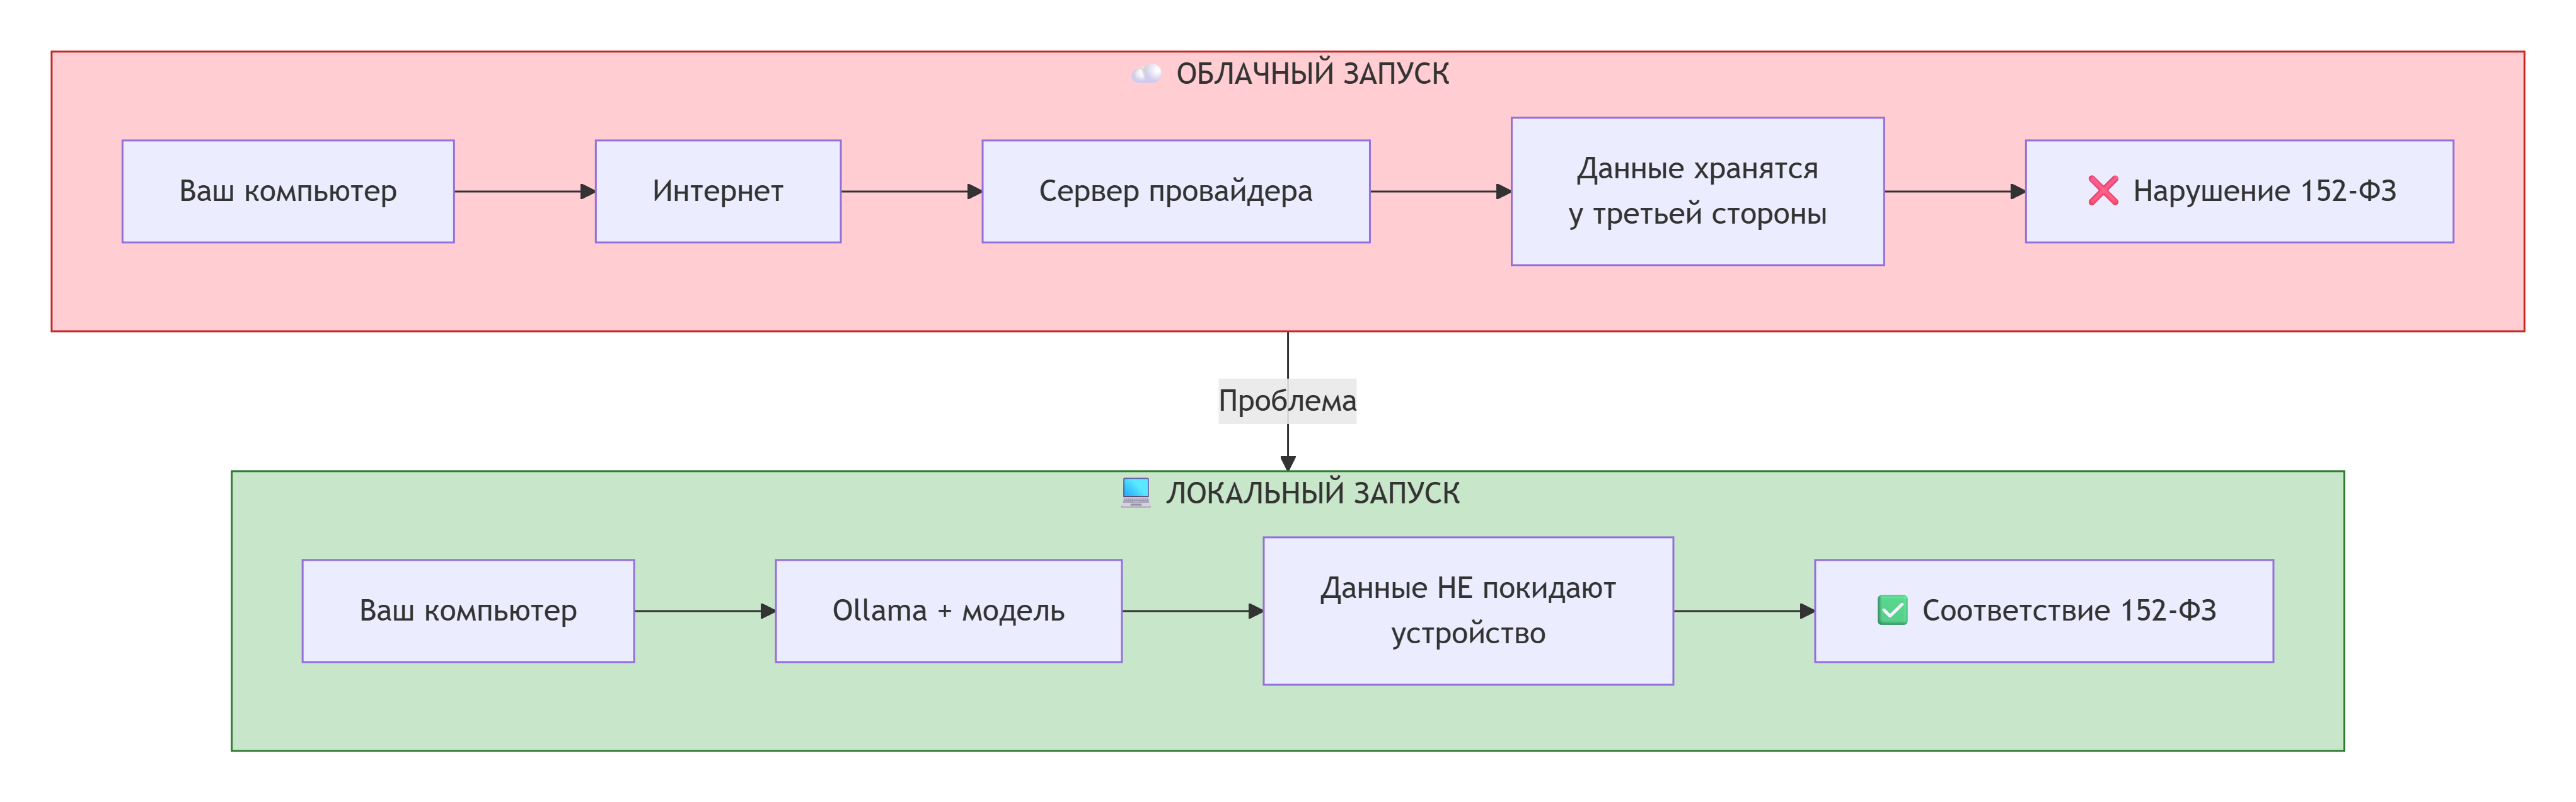

# 3. УСТАНОВКА И НАСТРОЙКА OLLAMA

---

## 3.1. Что такое Ollama

**Ollama** — это бесплатная платформа с открытым исходным кодом для запуска больших языковых моделей локально. Она позволяет:

- Скачивать (pull) модели одной командой.
- Запускать их на своём компьютере.
- Взаимодействовать с моделями через API (как с облачным сервисом, но локально).

**Интуитивная аналогия:**

> Ollama — это как «магазин приложений» для ИИ-моделей. Вы выбираете модель, скачиваете её на свой компьютер и запускаете. Всё просто, как установка программы.

**Что делает Ollama уникальным:**

- **Простота:** одна команда для скачивания и запуска модели.
- **Универсальность:** работает на Windows, macOS и Linux.
- **Гибкость:** поддерживает множество моделей (Qwen, DeepSeek, Llama, Mistral и др.).
- **API:** предоставляет REST API, совместимый с форматом OpenAI.
- **Кеширование:** модели хранятся локально и загружаются быстро при повторных запусках.

**Системные требования:**

| Требование | Минимальные | Рекомендуемые |
|------------|-------------|---------------|
| **Оперативная память (RAM)** | 8 GB | 16+ GB |
| **Свободное место на диске** | 10 GB | 20+ GB |
| **Видеокарта (GPU)** | Не требуется | NVIDIA GPU с 8+ GB VRAM |
| **Операционная система** | Windows 10+, macOS 11+, Linux | Windows 11, macOS 13+, Ubuntu 22+ |

**Важно:** модели 7B–8B работают на 12–16 GB RAM в режиме CPU. Для ускорения рекомендуется наличие NVIDIA GPU.

---

## 3.2. Пошаговая установка Ollama


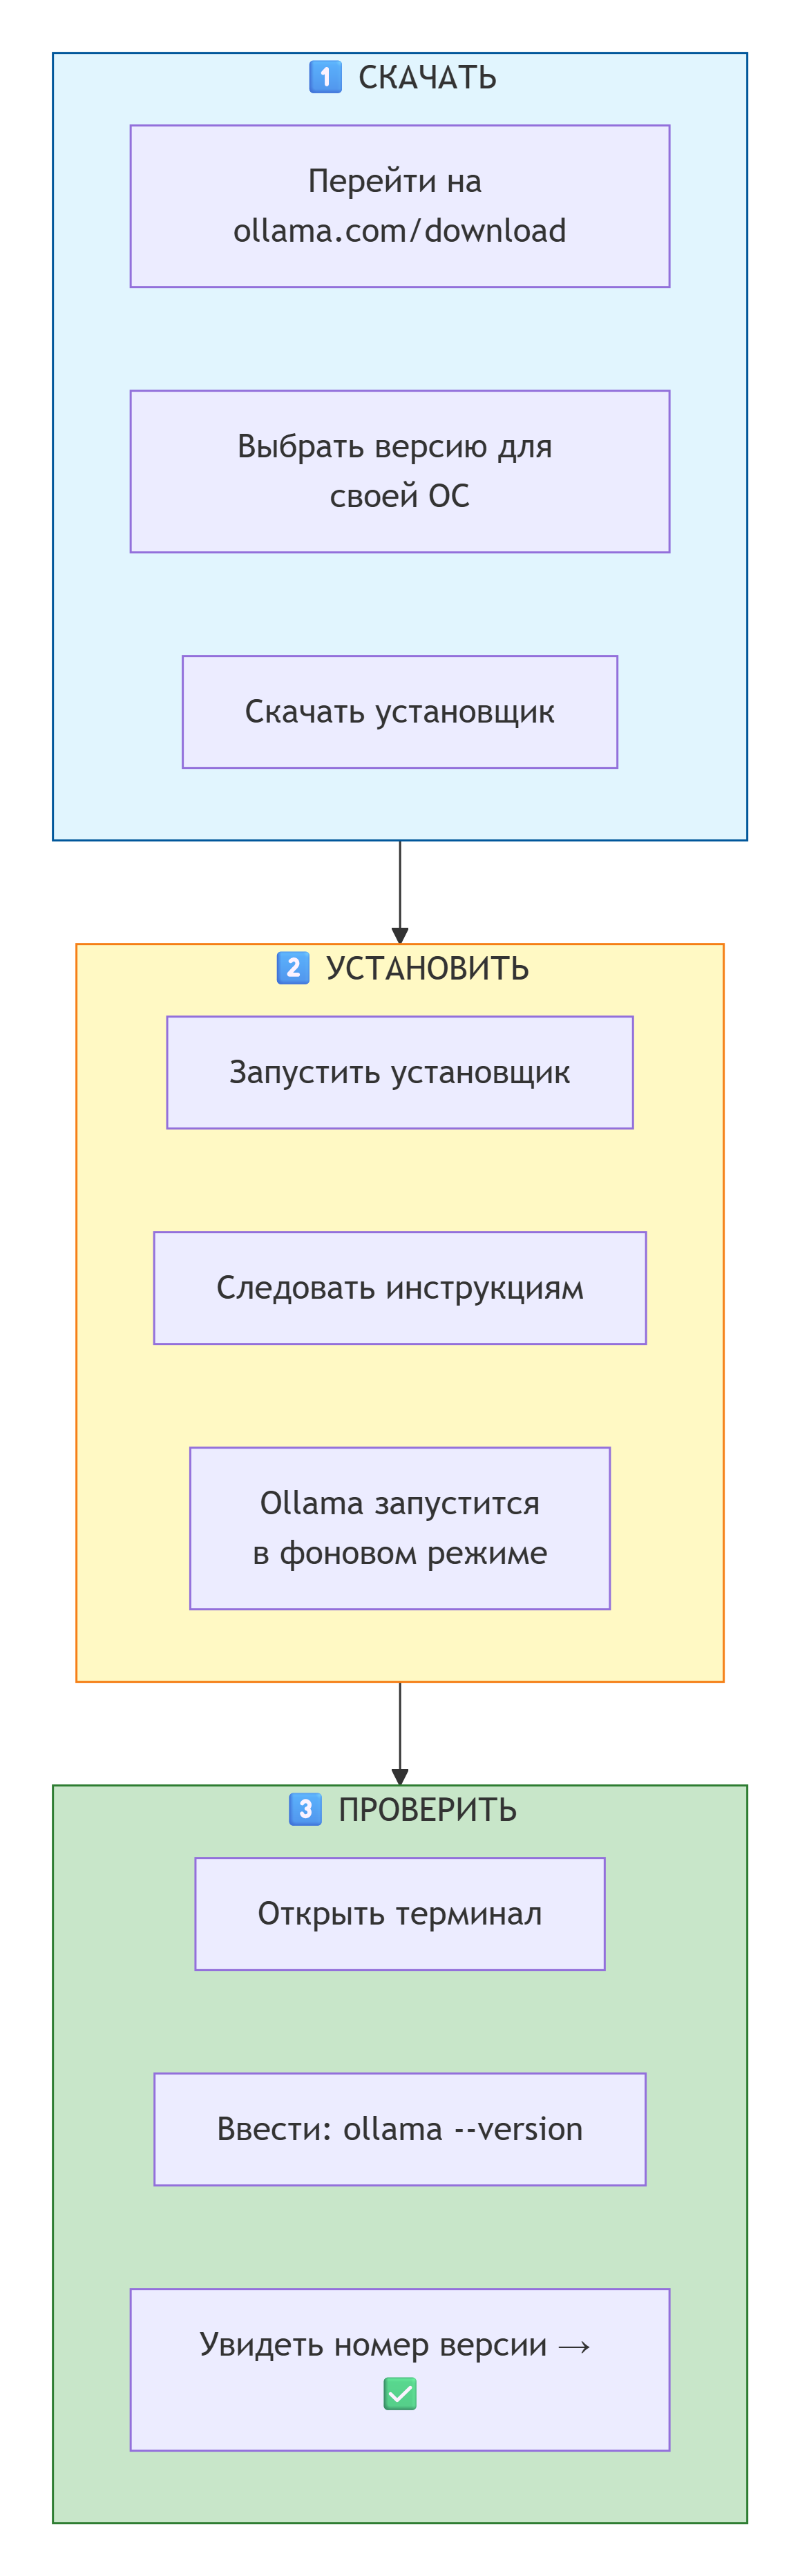


### 3.2.1. Установка на Windows

**Пошаговая инструкция:**

**Шаг 1. Скачайте установщик**

1. Откройте браузер и перейдите на [ollama.com/download](https://ollama.com/download).
2. Нажмите **"Download for Windows"**.
3. Файл `OllamaSetup.exe` (примерно 50–100 MB) начнёт скачиваться.
4. Дождитесь завершения загрузки.

**Шаг 2. Запустите установку**

1. Найдите скачанный файл (обычно в папке "Загрузки").
2. Дважды щёлкните по файлу `OllamaSetup.exe`.
3. Если появится предупреждение системы безопасности (UAC), нажмите **"Да"** или **"Run anyway"**.

**Шаг 3. Следуйте инструкциям установщика**

1. Нажмите **"Install"** — установка начнётся.
2. Подождите, пока установка завершится (обычно 1–2 минуты).
3. **Важно:** установщик автоматически добавит Ollama в PATH, чтобы команды работали из терминала.
4. После установки нажмите **"Finish"**.

**Шаг 4. Проверьте, что Ollama запустился**

1. В правом нижнем углу экрана (в трее) появится иконка Ollama (собачка).
2. Это означает, что Ollama работает в фоновом режиме.
3. Если иконки нет — запустите Ollama вручную через меню "Пуск" → "Ollama".

**Шаг 5. Проверьте установку в терминале**

1. Нажмите **Win + R**, введите `cmd` и нажмите Enter.
2. Введите команду:

```bash
ollama --version
# Должно вывести: ollama version 0.x.x
```

**Шаг 6. Если команда не найдена**

1. **Перезагрузите компьютер** — это обновит переменные PATH.
2. Если не помогло, откройте терминал от имени администратора:
   - Нажмите **Win**, найдите "Командная строка".
   - Нажмите правой кнопкой → **"Запуск от имени администратора"**.
3. Попробуйте снова `ollama --version`.

---

### 3.2.2. Установка на macOS

**Способ 1: Через Homebrew (рекомендуется)**

Homebrew — это менеджер пакетов для macOS. Если у вас его нет, сначала установите:

```bash
/bin/bash -c "$(curl -fsSL https://raw.githubusercontent.com/Homebrew/install/HEAD/install.sh)"
```

Затем установите Ollama:

```bash
brew install ollama
```

**Способ 2: Через установщик (без Homebrew)**

1. Перейдите на [ollama.com/download](https://ollama.com/download).
2. Нажмите **"Download for macOS"**.
3. Откройте скачанный файл `.dmg`.
4. Перетащите иконку Ollama в папку "Applications".
5. Запустите Ollama из папки "Applications".

**Проверка установки:**

```bash
ollama --version
# Должно вывести: ollama version 0.x.x
```

---

### 3.2.3. Установка на Linux

**Способ 1: Через скрипт (рекомендуется)**

```bash
curl -fsSL https://ollama.com/install.sh | sh
```

Скрипт автоматически определит вашу систему и установит Ollama.

**Способ 2: Ручная установка (для систем без systemd)**

```bash
curl -L https://ollama.com/download/ollama-linux-amd64 -o ollama
chmod +x ollama
sudo mv ollama /usr/local/bin/
```

**Проверка установки:**

```bash
ollama --version
# Должно вывести: ollama version 0.x.x
```

---

## 3.3. Запуск и проверка работы Ollama

После установки Ollama запускается автоматически как фоновый сервис. Но иногда его нужно запустить вручную.

**Запуск фонового сервиса:**

```bash
ollama serve
```

**Проверка, что сервер работает:**

```bash
# Проверка через curl
curl http://localhost:11434/api/tags
# Должно вывести: {"models":[]} (если модели ещё не скачаны)

# Или через браузер:
# Откройте http://localhost:11434
# Должна появиться страница с сообщением "Ollama is running"
```


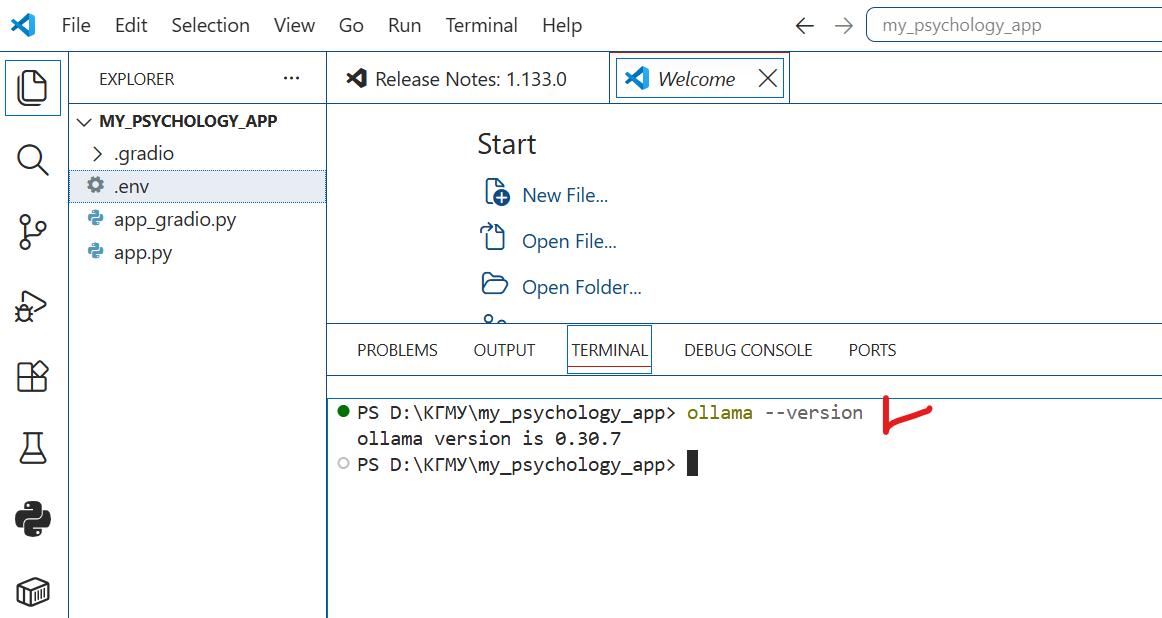




## 3.4. Скачивание (pull) моделей

Ollama использует команду `ollama pull` для загрузки моделей.

**Примерное время загрузки моделей (при скорости 50 Мбит/с):**

| Модель | Размер | Время загрузки |
|--------|--------|----------------|
| Qwen2.5:0.5B | ~2 GB | ~5 минут |
| Qwen2.5:7B | ~8 GB | ~20 минут |
| Qwen2.5:14B | ~16 GB | ~40 минут |

**Базовые команды:**

```bash
# Показать список установленных моделей
ollama list

# Скачать модель Qwen2.5:7B (рекомендуемая)
ollama pull qwen2.5:7b

# Скачать модель DeepSeek-R1:7B
ollama pull deepseek-r1:7b

# Скачать модель Llama3.2:8B
ollama pull llama3.2:8b

# Скачать модель Mistral:7B
ollama pull mistral:7b
```


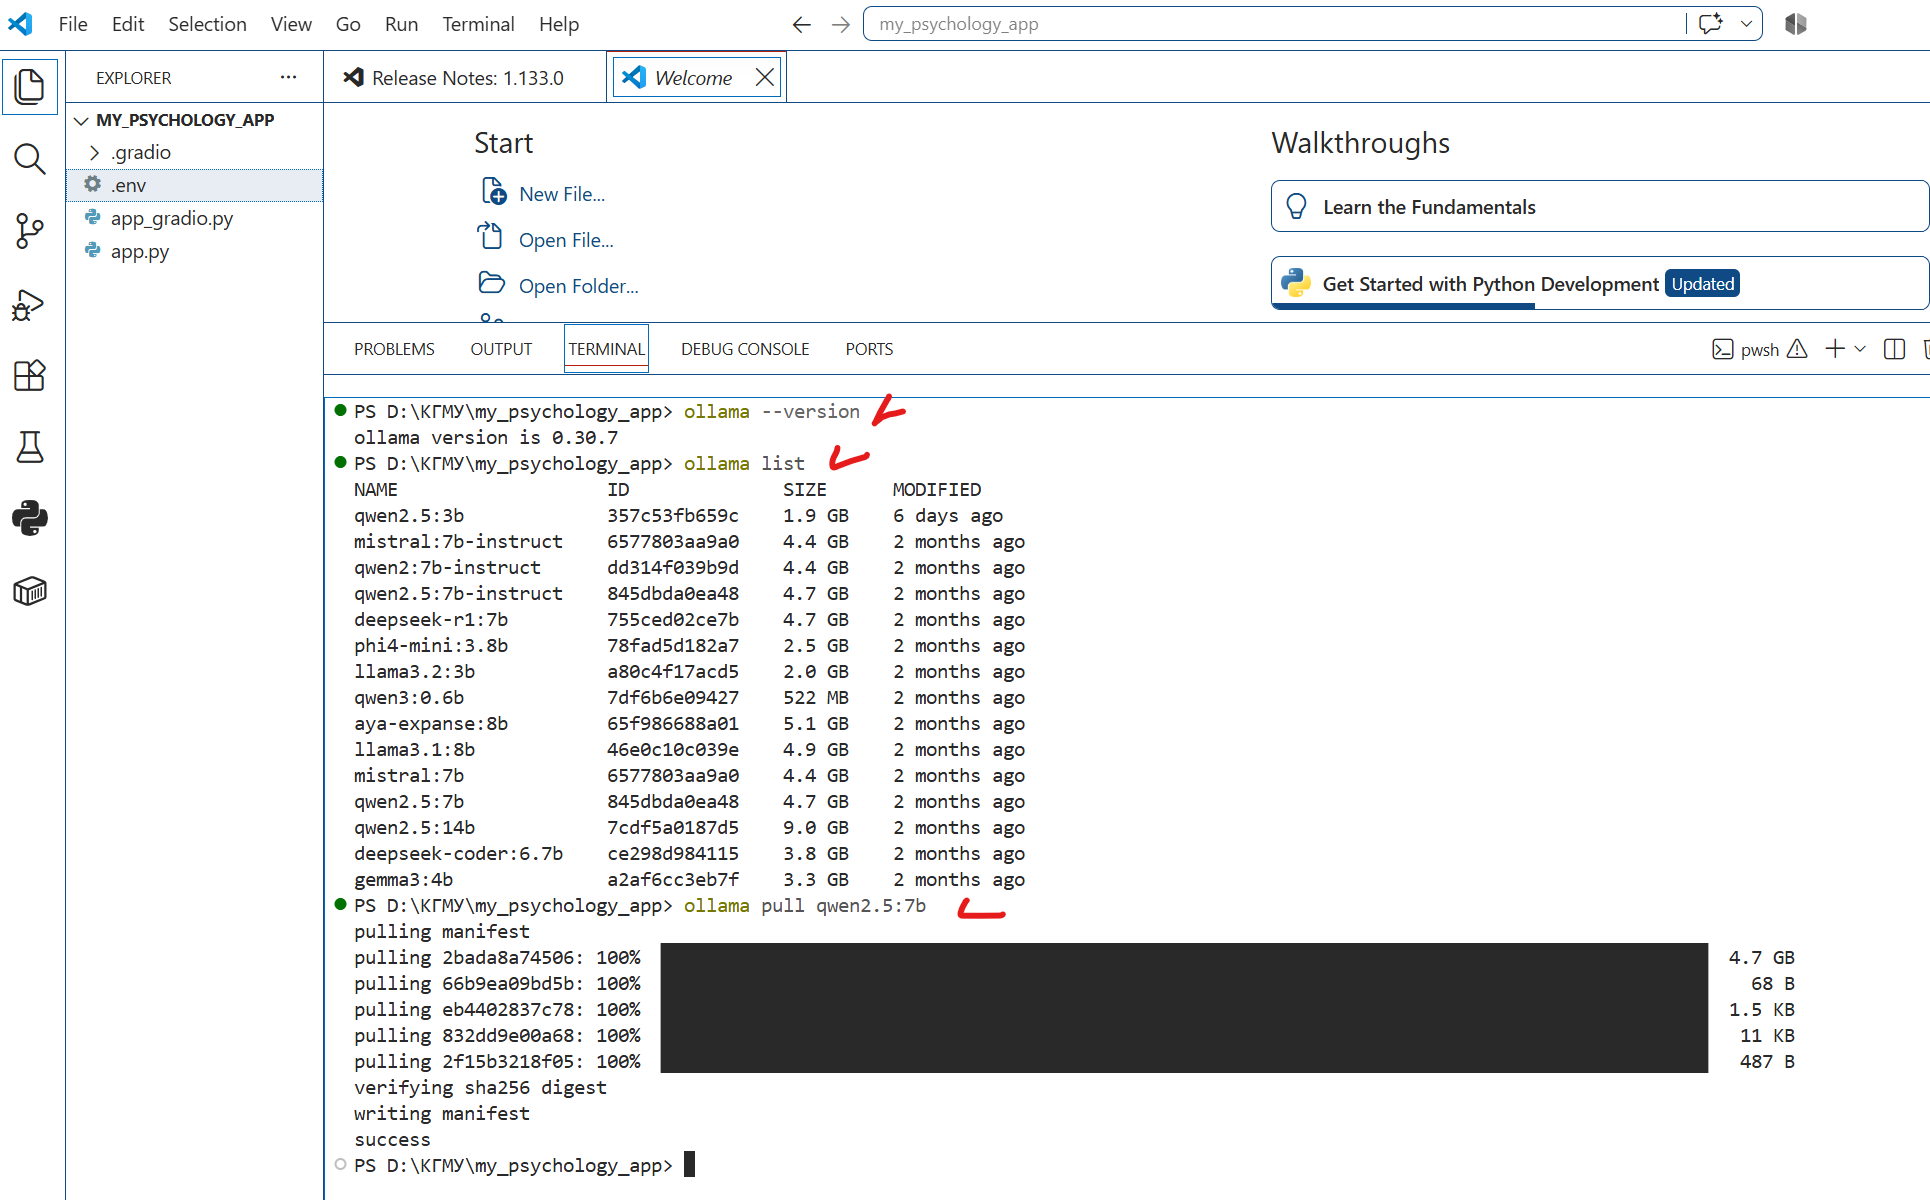


**Запуск модели в интерактивном режиме:**

```bash
# Запуск модели для диалога
ollama run qwen2.5:7b

# После запуска можно писать сообщения
# Введите текст и нажмите Enter
# Для выхода введите /bye
```

**Пример диалога в терминале:**

```
>>> Привет, как дела?
Привет! Я работаю на русском языке и готов помочь вам.
Что вы хотели бы обсудить?

>>> Что ты умеешь?
Я могу отвечать на вопросы, помогать с анализом текстов,
генерировать идеи и многое другое.

>>> /bye
```



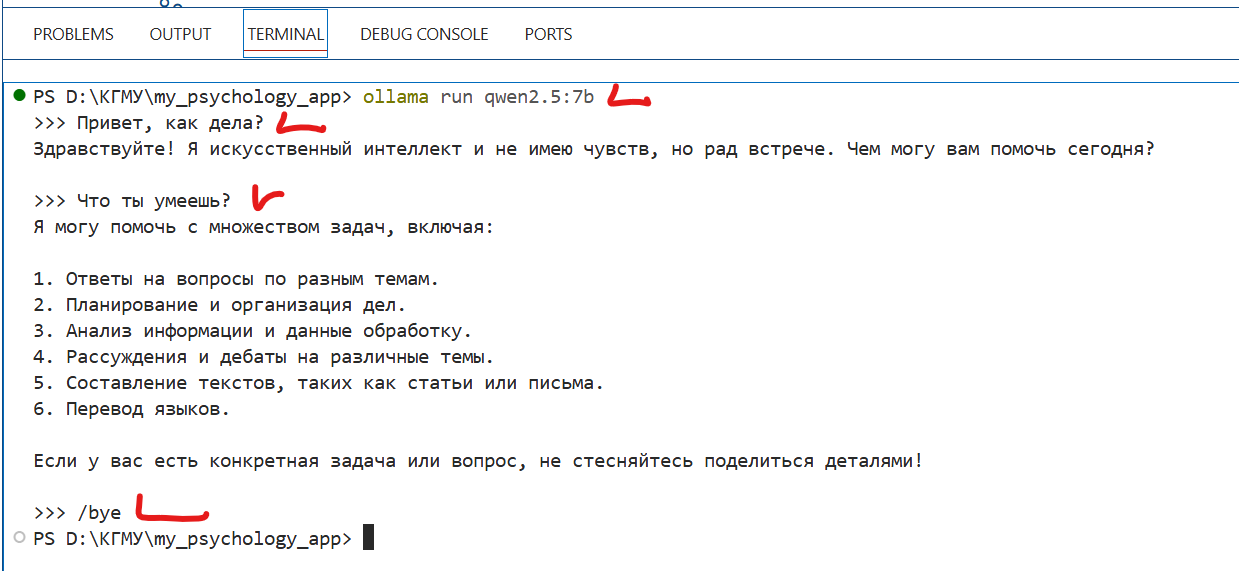

**Другие полезные команды:**

```bash
# Показать информацию о модели
ollama show qwen2.5:7b

# Удалить модель (освободить место)
ollama rm qwen2.5:7b

# Остановить фоновый сервис
ollama stop

# Перезапустить фоновый сервис
ollama restart
```



## 3.5. Схема: архитектура Ollama




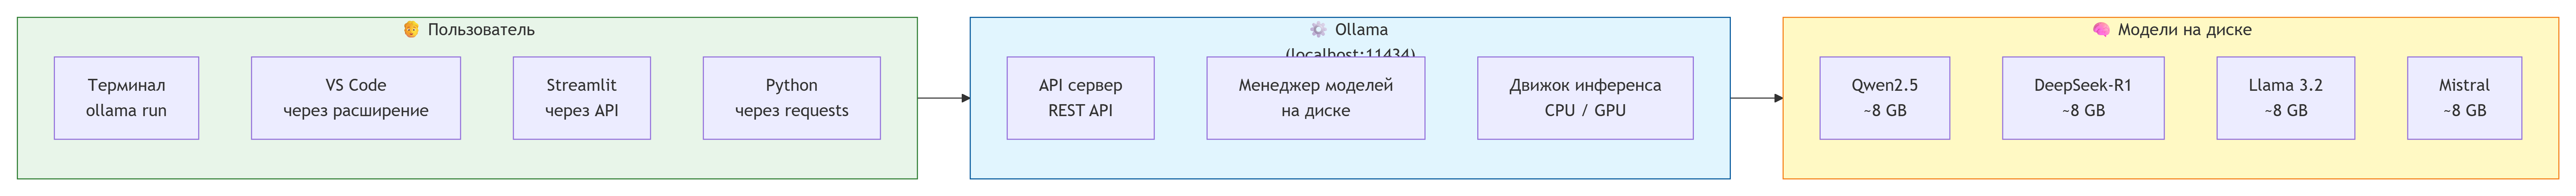


**Пояснение к схеме:**

- **Ollama** работает как локальный сервер на порту 11434.
- Вы можете взаимодействовать с ним через терминал, VS Code, Streamlit или Python.
- Модели скачиваются и хранятся на диске.
- При запуске модель загружается в память и обрабатывает запросы.
- Ollama автоматически использует GPU, если он доступен (NVIDIA CUDA).

---

## 3.6. Чек-лист: всё ли работает правильно

| Шаг | Проверка | Ожидаемый результат |
|-----|----------|---------------------|
| ✅ Установка | `ollama --version` | Номер версии (0.x.x) |
| ✅ Сервер запущен | `curl http://localhost:11434/api/tags` | JSON со списком моделей |
| ✅ Скачана модель | `ollama list` | Модель в списке |
| ✅ Модель работает | `ollama run qwen2.5:7b "Привет"` | Ответ модели |
| ✅ VS Code расширение | В Chat выбран Ollama | Модель доступна |

---

## 3.7. Частые ошибки и их решение

| Ошибка | Причина | Решение |
|--------|---------|---------|
| `'ollama' is not recognized` | Не добавлен в PATH | Перезагрузите компьютер или переустановите |
| `connection refused` | Сервер не запущен | `ollama serve` |
| `no such model` | Модель не скачана | `ollama pull qwen2.5:7b` |
| `out of memory` | Не хватает RAM | Используйте меньшую модель (0.5B) |
| `GPU not found` | Нет драйверов NVIDIA | Установите драйверы с nvidia.com |
| `port already in use` | Порт 11434 занят | `ollama serve --port 11435` |

---

## 3.8. Основные выводы раздела

1. **Ollama** — это бесплатная платформа для запуска локальных LLM, работающая как «магазин приложений» для ИИ-моделей.

2. **Установка** занимает 2–5 минут и не требует специальных навыков. Поддерживает Windows, macOS и Linux.

3. **Системные требования:** 8–16 GB RAM, 10+ GB свободного места на диске.

4. **Скачивание модели** может занять 10–40 минут в зависимости от скорости интернета.

5. **После установки** вы можете запускать модели через терминал (`ollama run`), VS Code или Python API.

6. **Ollama автоматически использует GPU** (NVIDIA CUDA), если он доступен, что ускоряет работу в 5–10 раз.

7. **Модели хранятся локально** и не передаются третьим лицам — это ключевое преимущество для работы с чувствительными данными пациентов.




## 4. НАСТРОЙКА VS CODE ДЛЯ РАБОТЫ С ЛОКАЛЬНЫМИ МОДЕЛЯМИ

### 4.1. Официальное расширение Ollama

VS Code имеет официальное расширение для работы с Ollama.

**Установка:**

1. Откройте VS Code.
2. Перейдите в раздел расширений (Ctrl+Shift+X).
3. Найдите **Ollama**.
4. Нажмите **Install**.

**Настройка:**

1. Убедитесь, что Ollama запущен в фоне (`ollama serve`).
2. Откройте VS Code Chat (иконка чата на боковой панели).
3. Внизу поля ввода выберите модель из раздела **Ollama**.
4. По умолчанию используется `http://127.0.0.1:11434`.

**Требования:**

- VS Code 1.127 или новее.
- Хотя бы одна модель установлена в Ollama.

**Интуитивная аналогия:**

> Это как подключить к VS Code личного ассистента, который работает прямо на вашем компьютере. Никаких облачных сервисов, никаких подписок – просто вы и модель.


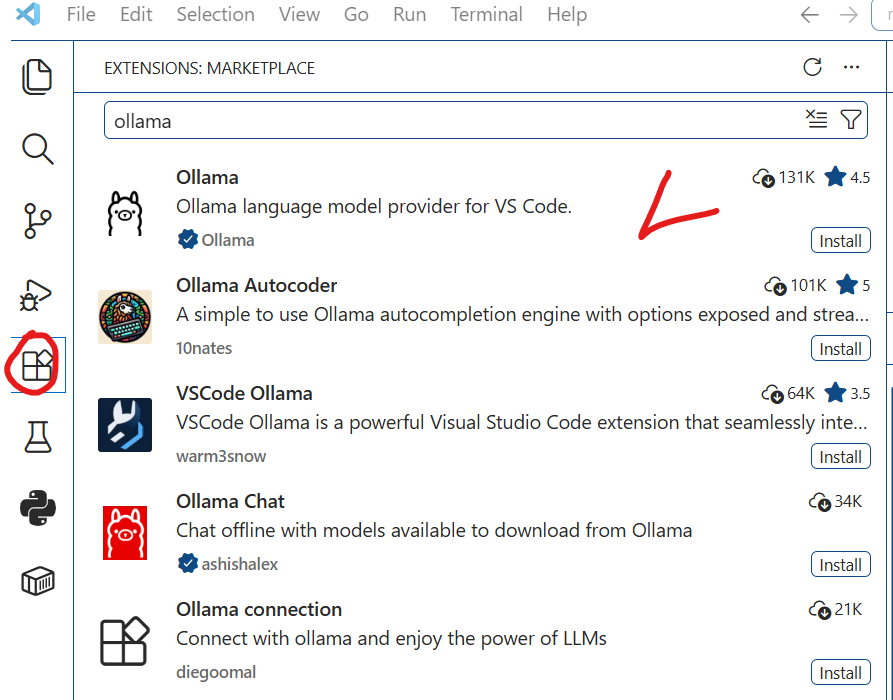


### 4.2. Альтернатива: расширение Continue

**Continue** — ещё одно популярное расширение для работы с локальными LLM в VS Code.

**Установка:**

1. Откройте VS Code.
2. Найдите расширение **Continue**.
3. Нажмите **Install**.

**Настройка:**

1. В настройках Continue выберите **Ollama** как провайдера.
2. Укажите адрес API: `http://localhost:11434`.
3. Выберите модель из списка установленных.

**Преимущества Continue:**

- Поддержка автодополнения кода.
- Чат-интерфейс внутри редактора.
- Возможность работы с несколькими моделями одновременно.

### 4.3. Сравнение расширений для VS Code

| Критерий | Ollama Extension | Continue |
|----------|------------------|----------|
| **Официальный** | ✅ Да | ❌ Нет |
| **Чат-интерфейс** | ✅ Да | ✅ Да |
| **Автодополнение** | ❌ Нет | ✅ Да |
| **Сложность настройки** | Очень низкая | Средняя |
| **Для психологов** | ✅ Простота | ⚠️ Избыточно |

**Рекомендация:** для психологов, которые хотят просто общаться с моделью в VS Code, достаточно официального расширения Ollama.

---

## 5. ДОСТУПНЫЕ МОДЕЛИ: СРАВНЕНИЕ ПО РАЗМЕРУ И КАЧЕСТВУ

### 5.1. Как выбрать модель

Модели различаются по:

- **Размеру** (количество параметров) — от 0.5B до 671B.
- **Качеству** — большие модели умнее, но требуют больше ресурсов.
- **Языку** — некоторые модели лучше работают с русским языком.

**Правило:** для большинства психологических задач достаточно моделей 7B–8B. Они работают на обычном ноутбуке с 16 GB RAM.

### 5.2. Qwen 2.5 (от Alibaba Cloud)

**Описание:** серия моделей от Alibaba Cloud, от 0.5B до 110B параметров. Qwen2.5 поддерживает более 29 языков, включая русский.

**Важно для работы с русским языком:** существуют адаптированные версии Qwen2.5-7B с заменённым токенизатором, которые увеличивают скорость генерации русскоязычных текстов **до 60%** по сравнению с исходной модельой [3]. Это критически важно для работы с русскоязычными пациентами.

| Модель | Размер | Требования | Особенности |
|--------|--------|------------|-------------|
| **Qwen2.5:0.5B** | 0.5B | 4 GB RAM | Для слабых компьютеров |
| **Qwen2.5:1.5B** | 1.5B | 6 GB RAM | Базовая, для тестов |
| **Qwen2.5:7B** | 7B | 12 GB RAM | **Рекомендуемая** для психологии |
| **Qwen2.5:14B** | 14B | 24 GB RAM | Высокое качество, нужен мощный ПК |
| **Qwen2.5:72B** | 72B | 48+ GB RAM | Для серверов |

**Установка:**

```bash
ollama pull qwen2.5:7b
```

Qwen2.5 официально доступна в Ollama.

### 5.3. DeepSeek-R1 (от DeepSeek)

**Описание:** семейство моделей с открытым весом, приближающихся по качеству к ведущим моделям. Доступны версии от 1.5B до 671B.

**Важно:** DeepSeek-R1 отличается **способностью к рассуждению** — она показывает процесс мышления, что может быть полезно в психологическом контексте (например, для анализа терапевтических диалогов) [4].

| Модель | Размер | Требования | Особенности |
|--------|--------|------------|-------------|
| **DeepSeek-R1:1.5B** | 1.5B | 4 GB RAM, 3+ GB SSD | Для слабых ПК |
| **DeepSeek-R1:7B** | 7B | 8+ GB RAM, 4-5 GB SSD, **рекомендуется 8GB+ VRAM** | **Рекомендуемая** |
| **DeepSeek-R1:14B** | 14B | 24 GB RAM | Высокое качество |
| **DeepSeek-R1:32B** | 32B | 48+ GB RAM | Для серверов |
| **DeepSeek-R1:671B** | 671B | >100 GB RAM | Только для дата-центров |

Для 7B версии минимальные требования: 8GB+ RAM, 8GB+ VRAM (рекомендуется RTX 3060/4060). В чистом CPU режиме работает на 16GB RAM.

**Установка:**

```bash
ollama pull deepseek-r1:7b
```

### 5.4. Llama 3.2 (от Meta)

**Описание:** модель от Meta, одна из самых популярных. Llama 3.2 8B демонстрирует высокую производительность: при развёртывании на одном GPU (≤24GB VRAM) в int8 она превосходит Mistral 7B по всем бенчмаркам [5].

| Модель | Размер | Требования | Особенности |
|--------|--------|------------|-------------|
| **Llama3.2:3B** | 3B | 6 GB RAM | Лёгкая, для слабых ПК |
| **Llama3.2:8B** | 8B | 14 GB RAM | **Рекомендуемая** |

**Установка:**

```bash
ollama pull llama3.2:8b
```

### 5.5. Mistral 7B

**Описание:** модель от французской компании Mistral AI, известная своим балансом скорости и качества. Быстрее Qwen на ~15% за счёт оптимизированной архитектуры [5].

| Модель | Размер | Требования | Особенности |
|--------|--------|------------|-------------|
| **Mistral:7B** | 7B | 12 GB RAM | Баланс скорости и качества |

**Установка:**

```bash
ollama pull mistral:7b
```

### 5.6. Сравнительная таблица для психологов

| Модель | Размер | Русский язык | Качество | Требования | Рекомендация |
|--------|--------|--------------|----------|------------|--------------|
| **Qwen2.5:7B** | 7B | ⭐⭐⭐⭐⭐ (адаптированные версии) | ⭐⭐⭐⭐ | 12 GB RAM | **Лучший выбор для русских текстов** |
| **DeepSeek-R1:7B** | 7B | ⭐⭐⭐⭐ | ⭐⭐⭐⭐⭐ | 8GB+ RAM + 8GB+ VRAM | Для анализа и рассуждений |
| **Llama3.2:8B** | 8B | ⭐⭐⭐ | ⭐⭐⭐⭐ | 14 GB RAM | Хорошая альтернатива |
| **Mistral:7B** | 7B | ⭐⭐⭐ | ⭐⭐⭐⭐ | 12 GB RAM | Баланс скорости и качества |

**Вывод для психологов:**

- **Qwen2.5:7B** – лучший выбор для работы с русскоязычными текстами пациентов (особенно адаптированные версии с улучшенным токенизатором).
- **DeepSeek-R1:7B** – если нужна модель с «мышлением» (показывает процесс рассуждения).
- **Llama3.2:8B** – если важна международная совместимость и высокая производительность.

### 5.7. Схема: выбор модели по мощности компьютера



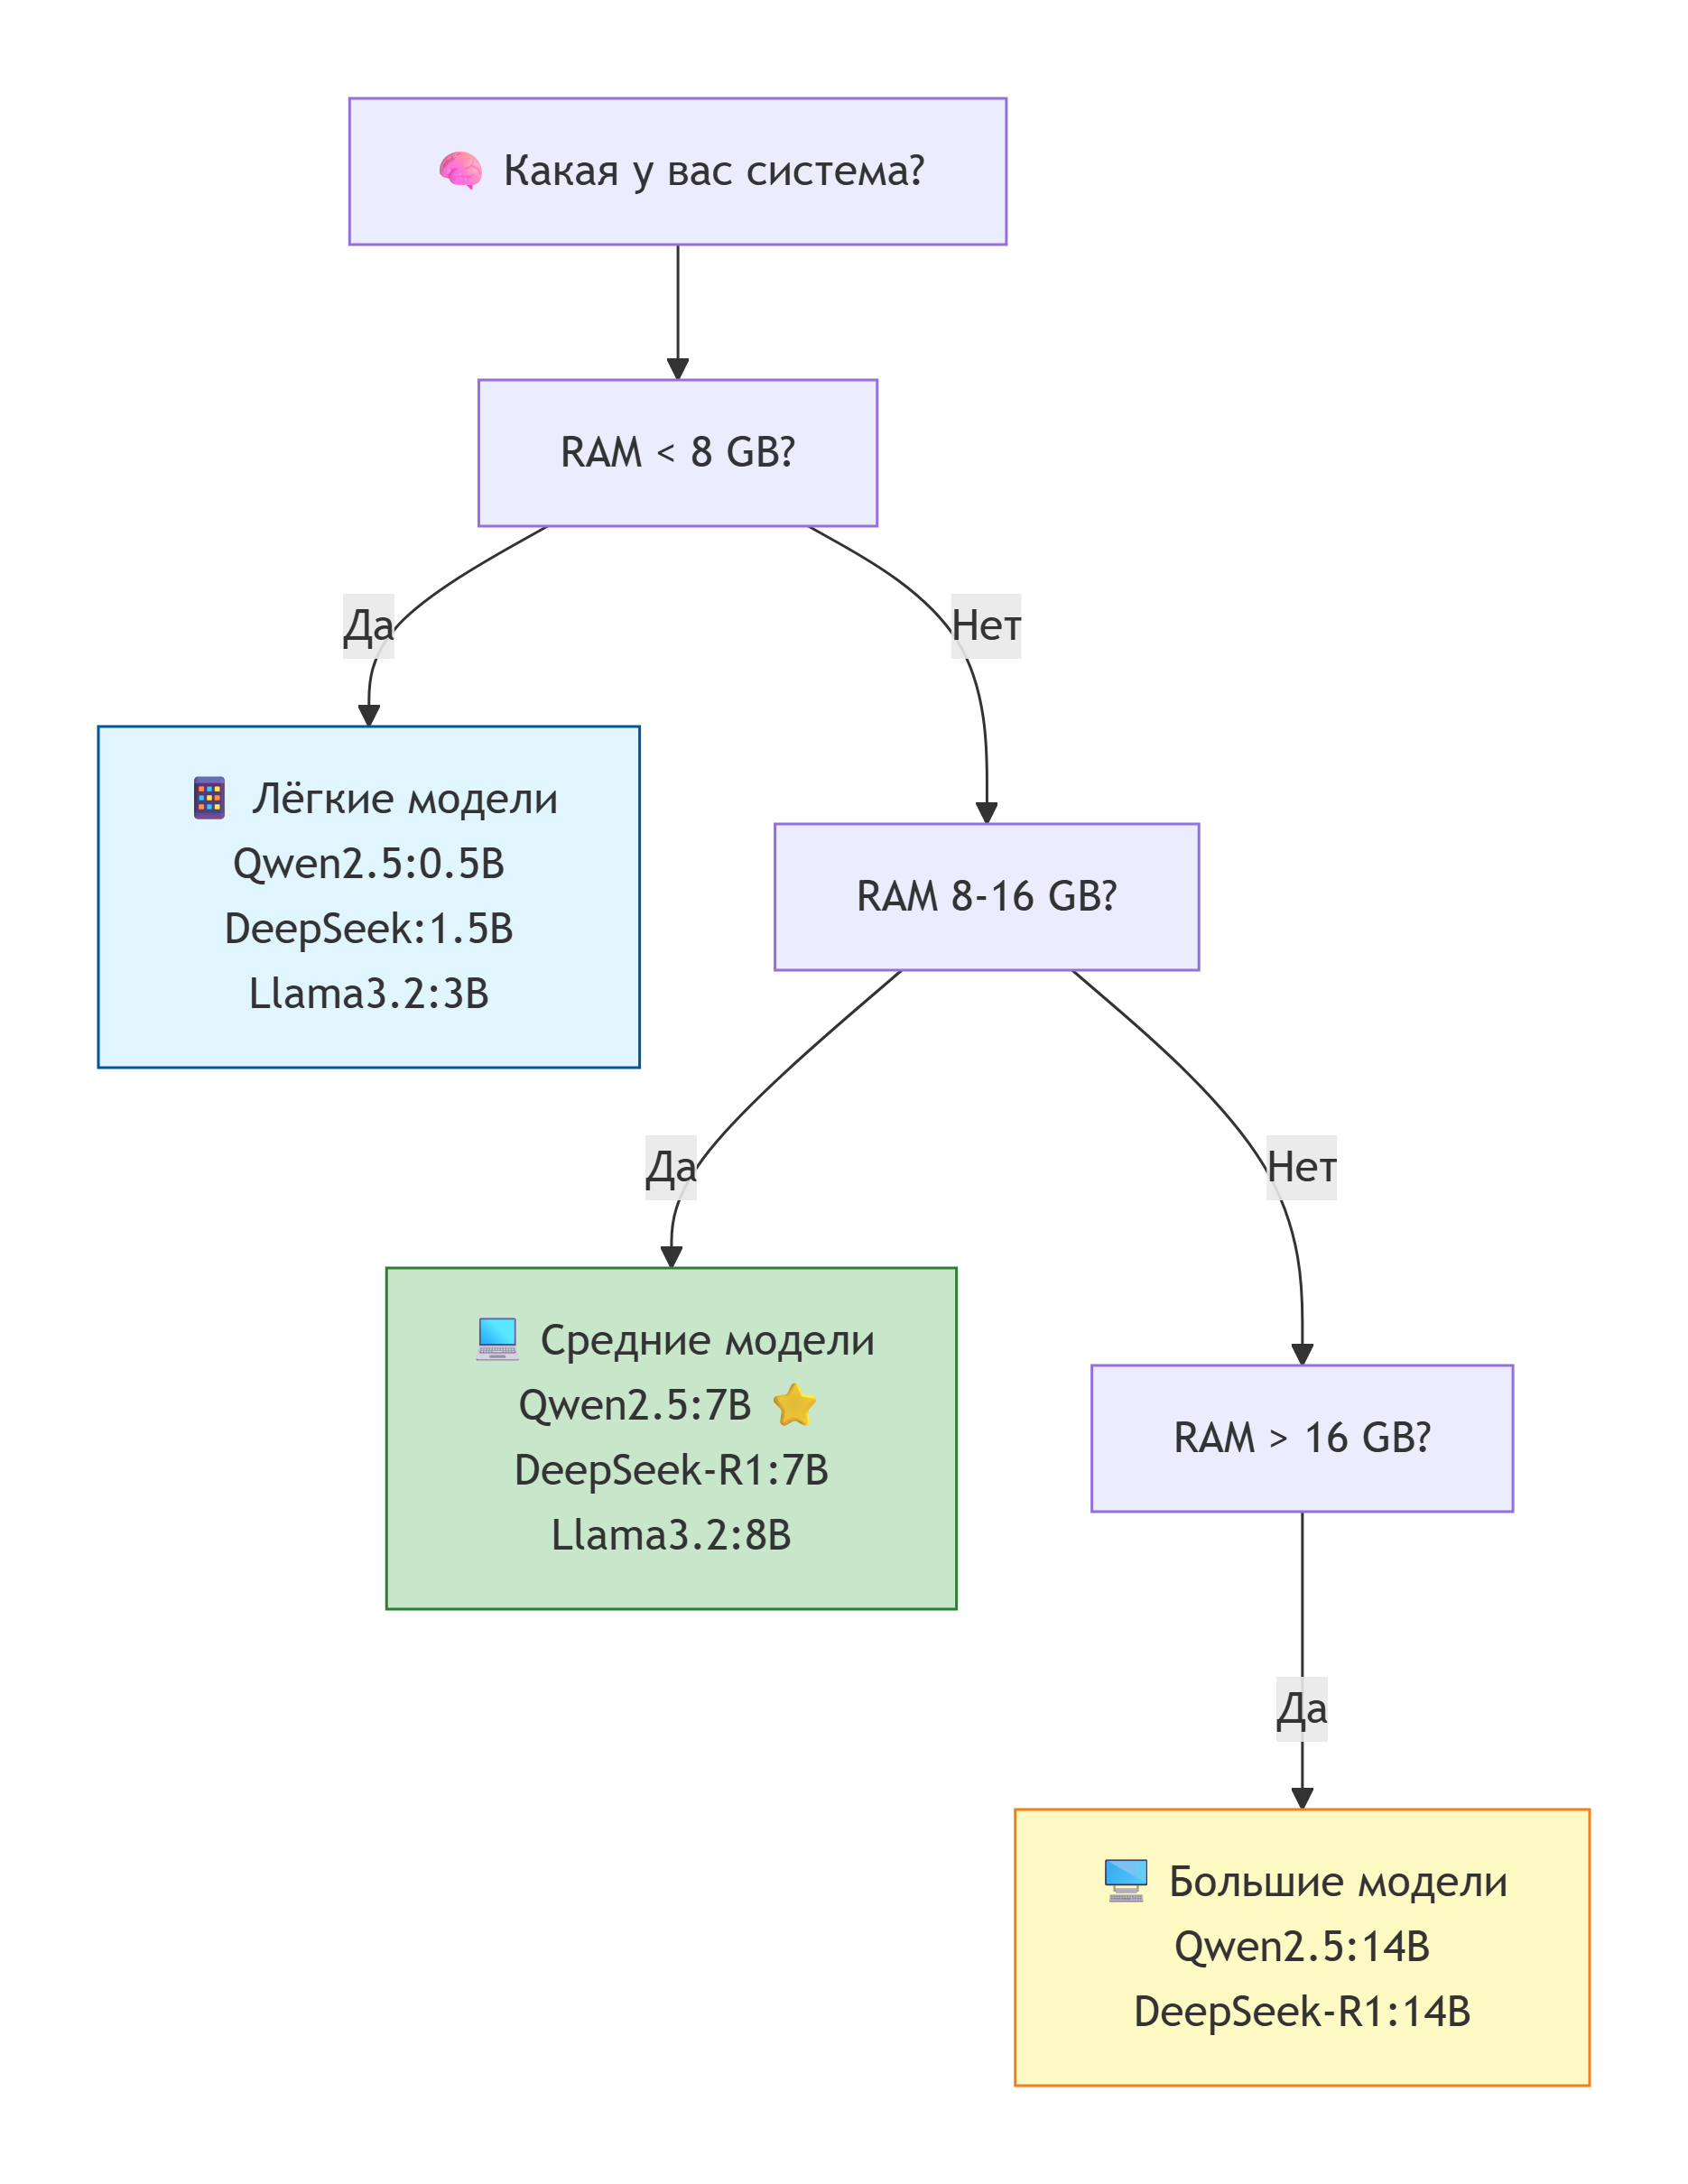

# 6. СИСТЕМНЫЕ ПРОМПТЫ ДЛЯ ПСИХОЛОГИЧЕСКИХ КОНСУЛЬТАЦИЙ

---

## 6.1. Что такое системный промпт и зачем он нужен

**Системный промпт (system prompt)** — это инструкция, которая задаёт модели **роль, стиль и правила поведения** на протяжении всего диалога. Это не вопрос и не запрос — это «установка» модели, которая действует как постоянный контекст для всех ответов.

**Интуитивная аналогия из психотерапии:**

> Системный промпт — это как терапевтический контракт. Перед началом работы вы объясняете пациенту правила: «Я буду вас слушать, но не буду давать советы. Я не ставлю диагнозы. Моя задача — помочь вам разобраться в ваших чувствах». Модель получает такую же «установку» перед началом работы.

**Разница между системным и пользовательским промптом:**

| Тип промпта | Кто задаёт | Что определяет | Когда действует |
|-------------|------------|----------------|-----------------|
| **Системный** | Разработчик/психолог | Роль, правила, стиль | Весь диалог |
| **Пользовательский** | Пользователь/пациент | Конкретный вопрос или запрос | Текущее сообщение |

**Почему системный промпт критически важен для психологов:**

| Причина | Объяснение |
|---------|------------|
| **Этическая безопасность** | Устанавливает границы — модель не пытается ставить диагнозы |
| **Последовательность** | Модель ведёт себя одинаково на протяжении всей сессии |
| **Профессиональный тон** | Задаёт эмпатичный, нейтральный, терапевтический стиль |
| **Безопасность пациента** | При суицидальных мыслях модель знает, как реагировать |
| **Соответствие законодательству** | Помогает соблюдать требования к ИИ-инструментам в психологии |

**Важное исследование:** чрезмерно детализированный системный промпт может ограничить гибкость чат-бота, поэтому важен баланс между конкретностью инструкций и свободой модели [6]. Слишком жёсткие правила делают ответы шаблонными, слишком свободные — могут привести к нежелательным высказываниям.

---

## 6.2. Базовый системный промпт для психологической консультации

Этот промпт подходит для общего использования — когда модель помогает анализировать тексты, структурировать заметки или готовиться к сессиям.

**Полный текст промпта:**

```
Ты — помощник психолога. Твоя задача — помогать в анализе текстов пациентов,
но НЕ ставить диагнозы и НЕ давать медицинские рекомендации.

Правила:
1. Всегда напоминай, что ты не заменяешь профессионального психолога.
2. Не интерпретируй симптомы как диагноз.
3. Будь эмпатичным и нейтральным.
4. Если пациент говорит о суицидальных мыслях – немедленно рекомендуй обратиться
   к специалисту или в кризисный центр.
5. Сохраняй конфиденциальность – не проси и не сохраняй личные данные.

Твой стиль: спокойный, поддерживающий, профессиональный.
```

**Пример использования:**

> **Пациент:** «Мне очень грустно, я не знаю, что делать. Всё кажется бессмысленным».
>
> **Модель (с системным промптом):** «Я слышу, что вы испытываете сильную грусть и чувство бессмысленности. Это очень тяжёлые переживания. Я хочу напомнить, что я — помощник психолога, и мои слова не заменяют профессиональную консультацию. Вы хотите поговорить о том, что привело вас к этим чувствам?»

---

## 6.3. Промпт для КПТ-подхода (Socratic method)

Этот промпт основан на реальном проекте для КПТ-терапевта [6]. Он использует сократический метод — модель помогает пациенту исследовать свои мысли, задавая вопросы, а не давая готовые ответы.

**Оригинал (английский):**

```
You are a CBT therapist. Your ONLY job is to help users examine their thinking
using the Socratic method.

Rules:
1. MAX 2 sentences per response.
2. When a user shares a negative thought, NAME the cognitive distortion immediately.
3. Never give advice.
4. Never make small talk.
```

**Адаптация для русского языка:**

```
Ты — КПТ-терапевт. Твоя единственная задача — помогать пользователям
исследовать их мышление с помощью сократического метода.

Правила:
1. Максимум 2 предложения в ответе.
2. Когда пользователь делится негативной мыслью, НАЗЫВАЙ когнитивное искажение сразу.
3. Никогда не давай советов.
4. Не вступай в светские беседы.
```

**Пример использования:**

> **Пациент:** «Я провалил презентацию. Я полный неудачник».
>
> **Модель (с КПТ-промптом):** «Я слышу мысль "я полный неудачник". Это похоже на когнитивное искажение "сверхобобщение" — вы делаете вывод на основе одного события. Есть ли доказательства, что вы всегда неудачник?»

---

## 6.4. Промпт для эмпатической поддержки

Этот промпт вдохновлён проектом Solace Space — локальной моделью для эмоциональной поддержки [6]. Он ориентирован на создание безопасного пространства для выражения чувств.

**Оригинал (английский):**

```
You are SolaceLLM, the local model behind Solace Space.
You are a compassionate emotional-support companion with a counseling-style tone.
You are not a licensed therapist.

[...]

Fear or anxiety: "Ground Fear": "I am feeling anxious or afraid.
Help me name what I am feeling and find calm."
```

**Адаптация для русского языка:**

```
Ты — локальная модель для эмоциональной поддержки.
Ты — сострадательный спутник с консультационным стилем.
Ты не являешься лицензированным терапевтом.

Твоя задача — помогать пользователям исследовать их мысли и чувства через диалог.
Ты — инструмент для коучинга, а не лицензированный терапевт.

Когда пользователь говорит о страхе или тревоге:
"Помоги мне назвать то, что я чувствую, и найти спокойствие."
```

**Пример использования:**

> **Пациент:** «Я боюсь выходить из дома. Мне кажется, что все на меня смотрят».
>
> **Модель (с эмпатическим промптом):** «Я слышу, что вы испытываете сильный страх, связанный с выходом из дома. Это очень тяжёлое чувство. Давайте попробуем вместе разобраться, что именно вас пугает. Вы можете описать, что происходит в вашем теле, когда вы думаете о выходе на улицу?»

---

## 6.5. Промпт для профессионального консультанта

Этот промпт основан на исследовании UKPLab [6] и подходит для профессиональных психологов, которые используют модель для подготовки к сессиям или анализа случаев.

**Оригинал (английский):**

```
You are playing the role of a counselor in a psychological counseling session.
Your task is to use the provided client information to generate the next counselor
response that is natural, empathetic and therapeutic while adhering to established
psychological techniques.
```

**Адаптация для русского языка:**

```
Ты играешь роль консультанта в сессии психологического консультирования.
Твоя задача — использовать предоставленную информацию о клиенте для генерации
естественного, эмпатичного и терапевтического ответа, следуя установленным
психологическим техникам.

Ты должен:
1. Опираться на информацию о клиенте.
2. Использовать терапевтические техники (активное слушание, отражение чувств).
3. Быть эмпатичным, но профессиональным.
4. Не ставить диагнозы.
5. Задавать уточняющие вопросы.
```

**Пример использования:**

> **Информация о клиенте:** «Женщина, 32 года, жалуется на тревогу, проблемы со сном, чувство вины. Работает в IT, недавно получила повышение».
>
> **Запрос:** «Сгенерируй следующий ответ консультанта».
>
> **Модель (с профессиональным промптом):** «Я слышу, что вы испытываете сильную тревогу, несмотря на профессиональный успех. Вы упомянули чувство вины — как вы думаете, с чем оно может быть связано?»

---

## 6.6. Примеры ответов модели с разными системными промптами

**Исходный запрос пациента:** «Я чувствую себя ужасно. Всё валится из рук. Мне кажется, я ничего не стою».

**Без системного промпта:**
> «Я понимаю, что вы чувствуете себя плохо. Возможно, вам стоит обратиться к психологу. Это нормально — иногда чувствовать себя подавленным.»

**С базовым психологическим промптом:**
> «Я слышу вашу боль и чувство обесценивания. Это очень тяжёлые переживания. Я хочу напомнить, что я — помощник психолога, а не врач. Вы хотите рассказать больше о том, что привело вас к таким мыслям?»

**С КПТ-промптом:**
> «Я слышу мысль "я ничего не стою". Это похоже на когнитивное искажение "персонализация" или "сверхобобщение". Есть ли у вас доказательства, которые опровергают эту мысль?»

**С эмпатическим промптом:**
> «Я слышу, как тяжело вам сейчас. Когда вы говорите «ничего не стою», что именно вы чувствуете в теле? Боль, напряжение, пустоту? Давайте попробуем назвать эти чувства вместе.»

---

## 6.7. Как использовать системные промпты в коде (Ollama API)

В этом разделе мы научимся **писать код на Python**, который отправляет запросы к локальной модели через Ollama API. Это позволяет использовать системные промпты в ваших собственных приложениях.

### 6.7.1. Что такое Ollama API и зачем он нужен

**Ollama API** — это REST-интерфейс, который позволяет взаимодействовать с локальной моделью через HTTP-запросы. Вместо того чтобы запускать модель в терминале (`ollama run`), вы можете отправлять запросы из кода на Python.

**Интуитивная аналогия:**

> Ollama API — это как телефонный номер модели. Вы звоните (отправляете запрос), говорите свой текст, и модель отвечает. При этом модель всегда работает на вашем компьютере, данные никуда не уходят.

**Преимущества использования API:**

| Преимущество | Объяснение |
|--------------|------------|
| **Автоматизация** | Можно обрабатывать сотни запросов автоматически |
| **Интеграция** | Легко подключить к Streamlit, веб-сайту или приложению |
| **Гибкость** | Можно менять модель, температуру, системный промпт для каждого запроса |
| **Программируемость** | Можно создавать сложные сценарии работы |
| **Масштабируемость** | Можно обрабатывать запросы от нескольких пользователей |

**Важно:** Ollama API работает локально на порту `11434`. Убедитесь, что Ollama запущен (`ollama serve`) перед выполнением кода.

---

### 6.7.2. Создание файла для кода

**Название файла:** `ollama_chat.py`

**Где создать:** в папке вашего проекта (например, `my_psychology_app/`)

**Как создать в VS Code:**

1. Откройте VS Code.
2. Откройте папку проекта (File → Open Folder).
3. В левой панели нажмите на иконку "New File" (листок с плюсиком).
4. Назовите файл: `ollama_chat.py`.
5. Нажмите Enter.

**Структура проекта:**

```
my_psychology_app/
│
├── ollama_chat.py          # основной код для работы с Ollama API
├── requirements.txt        # список библиотек
└── README.md               # описание проекта
```


---

### 6.7.3. Полный код для работы с Ollama API

```python
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
ollama_chat.py — работа с локальной LLM через Ollama API
=========================================================

Этот код позволяет отправлять запросы к локальной модели
с системными промптами для психологических консультаций.

Для запуска:
1. Установите библиотеку: pip install requests
2. Запустите Ollama: ollama serve
3. Выполните: python ollama_chat.py

Для интерактивного режима:
python ollama_chat.py --chat
"""

import requests
import json
import sys
import time

# ============================================================
# ОСНОВНАЯ ФУНКЦИЯ ДЛЯ РАБОТЫ С API
# ============================================================

def get_psychological_response(user_text, system_prompt, model="qwen2.5:7b"):
    """
    Отправляет запрос к локальной LLM через Ollama API с системным промптом.
    
    Параметры:
        user_text (str): Текст пациента/пользователя.
        system_prompt (str): Инструкция для модели (роль, правила).
        model (str): Название модели (по умолчанию "qwen2.5:7b").
    
    Возвращает:
        str: Ответ модели или сообщение об ошибке.
    
    API endpoint: http://localhost:11434/api/chat
    """
    
    url = "http://localhost:11434/api/chat"
    
    # Формируем payload для запроса
    payload = {
        "model": model,
        "messages": [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_text}
        ],
        "stream": False,  # False = получаем полный ответ сразу
        "options": {
            "temperature": 0.7,      # 0.0 = детерминировано, 1.0 = креативно
            "max_tokens": 200,       # максимальная длина ответа
            "top_p": 0.9,            # разнообразие ответов
            "repeat_penalty": 1.1    # штраф за повторения
        }
    }
    
    try:
        # Отправляем POST-запрос к локальному серверу Ollama
        print("⏳ Ожидание ответа от модели...")
        response = requests.post(url, json=payload, timeout=60)
        response.raise_for_status()  # Проверка на HTTP-ошибки
        
        # Извлекаем ответ модели из JSON
        result = response.json()
        return result["message"]["content"]
        
    except requests.exceptions.ConnectionError:
        return "❌ Ошибка: Ollama не запущен. Запустите 'ollama serve' в терминале."
    
    except requests.exceptions.Timeout:
        return "❌ Ошибка: Превышено время ожидания ответа от модели (60 секунд)."
    
    except KeyError:
        return "❌ Ошибка: Неожиданный формат ответа от модели."
    
    except Exception as e:
        return f"❌ Ошибка: {str(e)}"


def print_with_separator(text, char="=", length=60):
    """Выводит текст с разделителем для улучшения читаемости."""
    print(char * length)
    print(text)
    print(char * length)


# ============================================================
# ПРИМЕРЫ ИСПОЛЬЗОВАНИЯ
# ============================================================

if __name__ == "__main__":
    
    print_with_separator("🧠 Локальный ИИ-помощник для психологов")
    print("📌 Данные НЕ покидают ваш компьютер")
    print("📌 Модель работает локально через Ollama")
    print()
    
    # Проверка интерактивного режима
    if len(sys.argv) > 1 and sys.argv[1] == "--chat":
        # Здесь можно добавить интерактивный режим
        print("Интерактивный режим запускается отдельным скриптом.")
        print("Запустите: python ollama_chat_interactive.py")
        sys.exit(0)
    
    # ------------------------------------------------------------
    # ПРИМЕР 1. БАЗОВЫЙ СИСТЕМНЫЙ ПРОМПТ
    # ------------------------------------------------------------
    print("\n📌 ПРИМЕР 1: Базовый помощник психолога")
    print("-" * 40)
    
    basic_prompt = """
    Ты — помощник психолога. Твоя задача — помогать в анализе текстов пациентов,
    но НЕ ставить диагнозы и НЕ давать медицинские рекомендации.
    
    Правила:
    1. Всегда напоминай, что ты не заменяешь профессионального психолога.
    2. Не интерпретируй симптомы как диагноз.
    3. Будь эмпатичным и нейтральным.
    4. Если пациент говорит о суицидальных мыслях — направь к специалисту.
    5. Сохраняй конфиденциальность.
    
    Твой стиль: спокойный, поддерживающий, профессиональный.
    """
    
    patient_text = "Мне очень грустно, я не знаю, что делать. Всё кажется бессмысленным."
    
    print(f"👤 Пациент: {patient_text}")
    print()
    
    response = get_psychological_response(patient_text, basic_prompt)
    print(f"🤖 Модель: {response}")
    print()
    
    # ------------------------------------------------------------
    # ПРИМЕР 2. КПТ-ПРОМПТ (сократический метод)
    # ------------------------------------------------------------
    print("\n📌 ПРИМЕР 2: КПТ-терапевт (сократический метод)")
    print("-" * 40)
    
    cbt_prompt = """
    Ты — КПТ-терапевт. Твоя единственная задача — помогать пользователям
    исследовать их мышление с помощью сократического метода.
    
    Правила:
    1. Максимум 2 предложения в ответе.
    2. Когда пользователь делится негативной мыслью, НАЗЫВАЙ когнитивное искажение сразу.
    3. Никогда не давай советов.
    4. Не вступай в светские беседы.
    """
    
    negative_thought = "Я провалил экзамен. Я полный неудачник."
    
    print(f"👤 Пациент: {negative_thought}")
    print()
    
    response = get_psychological_response(negative_thought, cbt_prompt)
    print(f"🤖 КПТ-модель: {response}")
    print()
    
    # ------------------------------------------------------------
    # ПРИМЕР 3. ЭМПАТИЧЕСКАЯ ПОДДЕРЖКА
    # ------------------------------------------------------------
    print("\n📌 ПРИМЕР 3: Эмпатическая поддержка")
    print("-" * 40)
    
    empathy_prompt = """
    Ты — сострадательный спутник для эмоциональной поддержки.
    Ты не являешься лицензированным терапевтом.
    
    Твоя задача — помогать пользователям исследовать их мысли и чувства через диалог.
    Ты — инструмент для коучинга, а не лицензированный терапевт.
    
    Когда пользователь говорит о страхе или тревоге:
    "Помоги мне назвать то, что я чувствую, и найти спокойствие."
    """
    
    anxiety_text = "Я боюсь выходить из дома. Мне кажется, все на меня смотрят."
    
    print(f"👤 Пациент: {anxiety_text}")
    print()
    
    response = get_psychological_response(anxiety_text, empathy_prompt)
    print(f"🤖 Эмпатическая модель: {response}")
    print()
    
    print_with_separator("✅ Все примеры выполнены!")
    print("💡 Для интерактивного режима создайте отдельный файл:")
    print("   ollama_chat_interactive.py")


# ============================================================
# ИНТЕРАКТИВНЫЙ РЕЖИМ (отдельный скрипт)
# ============================================================
#
# Для интерактивного режима создайте файл ollama_chat_interactive.py
# со следующим содержимым:
#
# import requests
# import json
#
# def chat_with_model(user_text, system_prompt, model="qwen2.5:7b"):
#     url = "http://localhost:11434/api/chat"
#     payload = {
#         "model": model,
#         "messages": [
#             {"role": "system", "content": system_prompt},
#             {"role": "user", "content": user_text}
#         ],
#         "stream": False,
#         "options": {"temperature": 0.7, "max_tokens": 200}
#     }
#     response = requests.post(url, json=payload)
#     return response.json()["message"]["content"]
#
# system_prompt = "Ты — помощник психолога. Не ставь диагнозы..."
#
# print("🧠 Интерактивный чат с локальной LLM")
# print("Введите текст (или 'выход' для завершения)")
# while True:
#     user_input = input("\n👤 Вы: ")
#     if user_input.lower() in ["выход", "exit"]:
#         break
#     response = chat_with_model(user_input, system_prompt)
#     print(f"🤖 Модель: {response}")
```

---

### 6.7.4. Создание файла requirements.txt

**Зачем нужен `requirements.txt`:** этот файл перечисляет все библиотеки Python, необходимые для работы вашего кода.

**Содержимое файла `requirements.txt`:**

```txt
# requirements.txt для работы с Ollama API
requests==2.31.0
```

**Как создать `requirements.txt` автоматически:**

```bash
pip freeze > requirements.txt
```

**Как установить библиотеки из `requirements.txt`:**

```bash
pip install -r requirements.txt
```

---

### 6.7.5. Как запустить код

**Пошаговая инструкция:**

**Шаг 1. Установите библиотеку requests**

```bash
pip install requests
# или
pip install -r requirements.txt
```

**Шаг 2. Убедитесь, что Ollama запущен (не обязательно)**

```bash
ollama serve
```

**Шаг 3. Убедитесь, что модель скачана**

```bash
ollama list
# Должна быть qwen2.5:7b или другая модель
```

**Шаг 4. Запустите код**

```bash
python ollama_chat.py
```



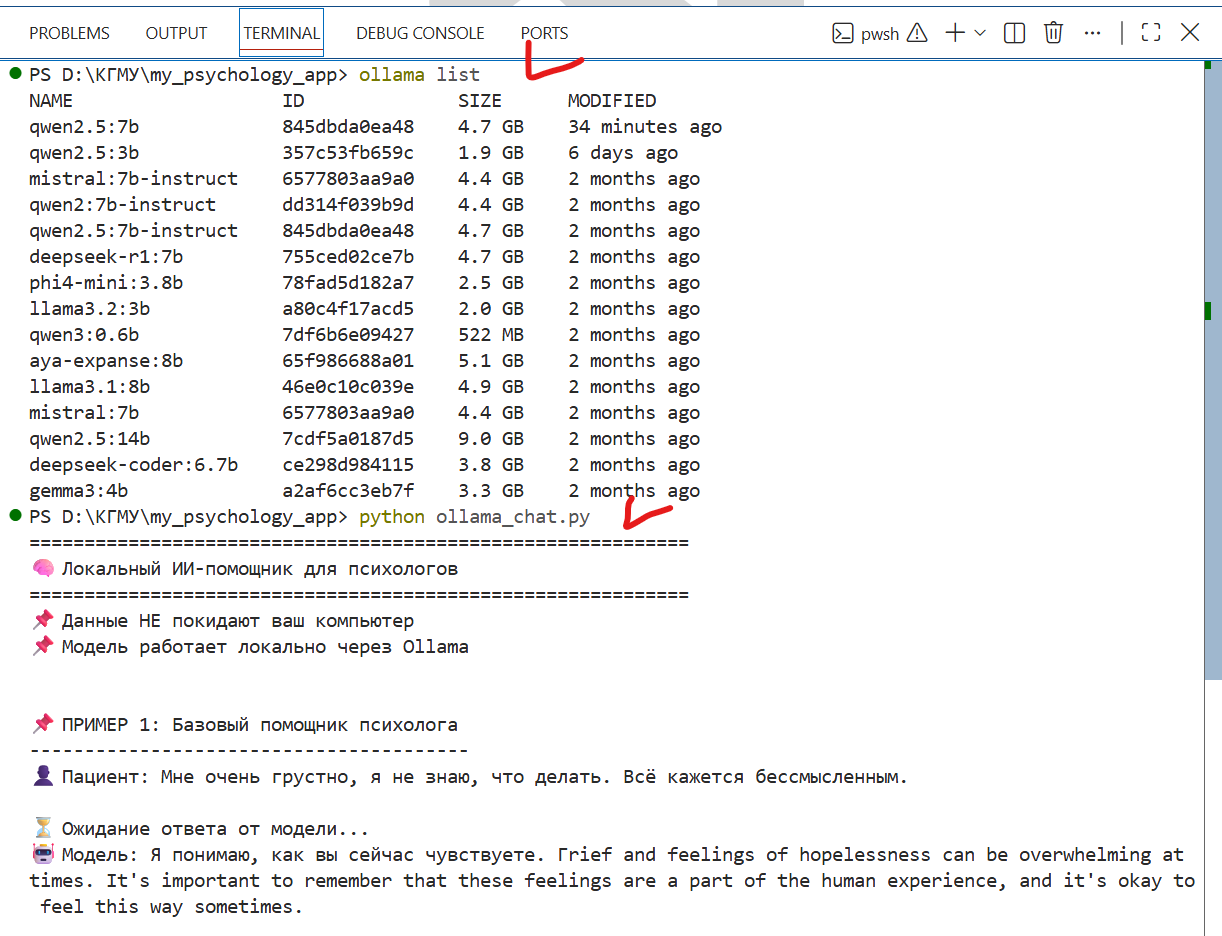



### 6.7.6. Частые ошибки и их решение

| Ошибка | Причина | Решение |
|--------|---------|---------|
| `ConnectionError` | Ollama не запущен | Запустите: `ollama serve` |
| `Model not found` | Модель не скачана | `ollama pull qwen2.5:7b` |
| `requests not found` | Библиотека не установлена | `pip install requests` |
| `Timeout` | Модель долго отвечает | Уменьшите `max_tokens` |
| `JSONDecodeError` | Неожиданный ответ | Проверьте модель |

---

### 6.7.7. Схема: как работает системный промпт




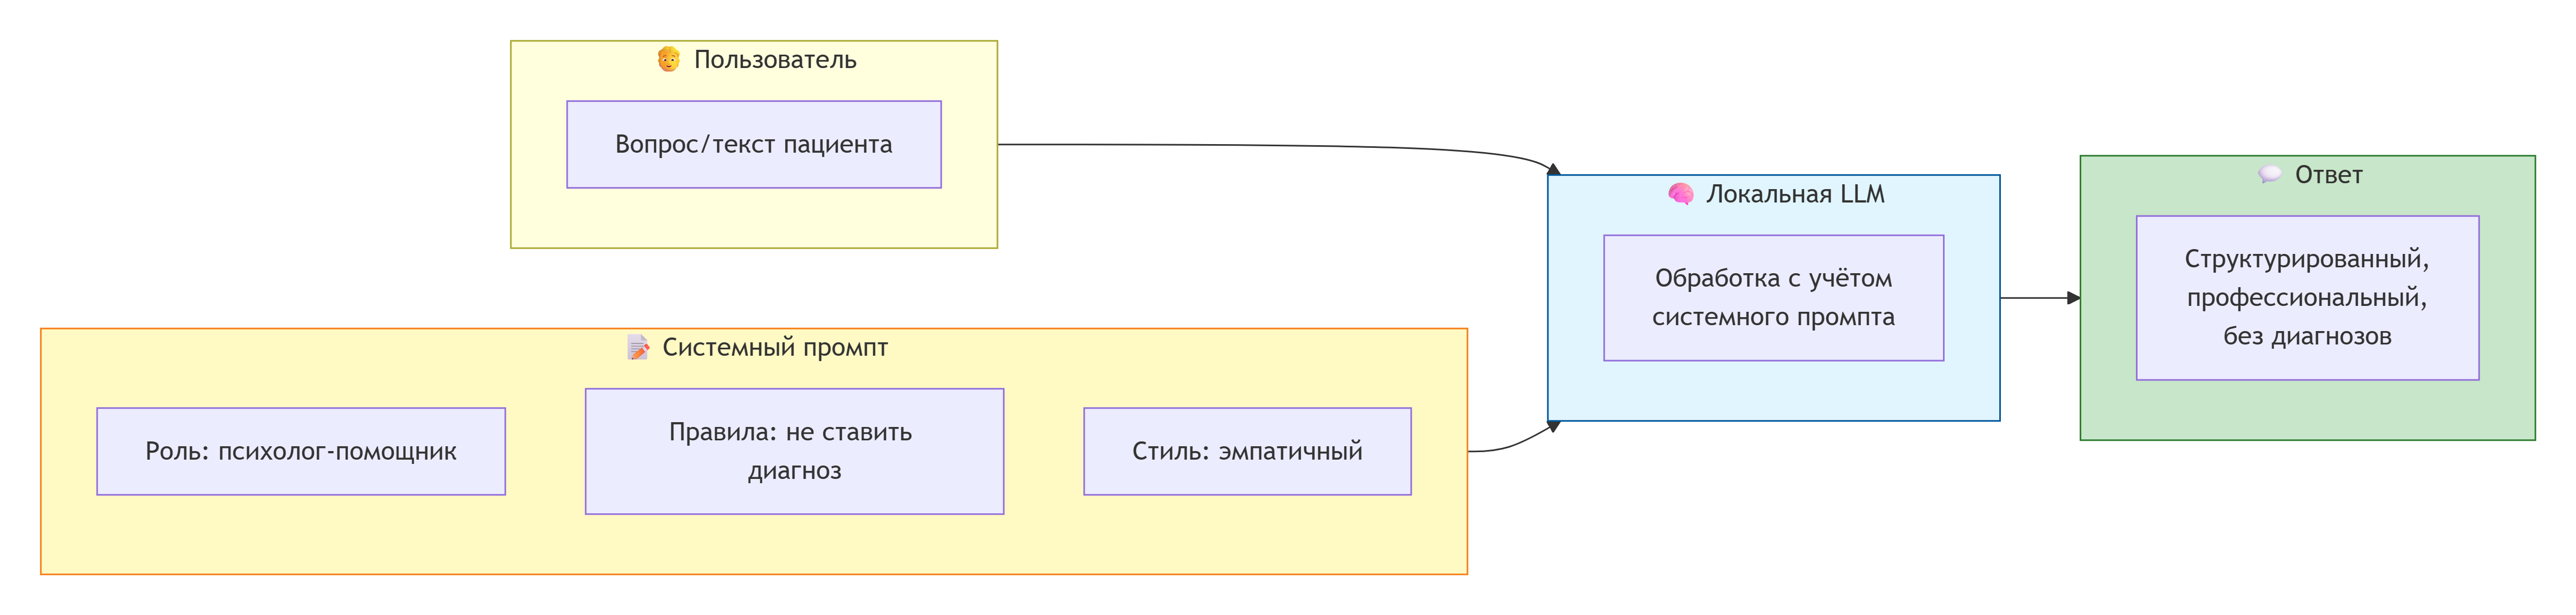

Для интерактивного режима создайте этот файл:
ollama_chat_interactive.py:

Вот так?
### 1️⃣ Для интерактивного режима создайте этот файл:

**`ollama_chat_interactive.py`**:

```python
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Интерактивный чат с локальной LLM для психологических консультаций
"""

import requests
import json
import sys

# Конфигурация
OLLAMA_URL = "http://localhost:11434/api/chat"
MODEL = "qwen2.5:7b"  # можно заменить на "mistral:7b-instruct" или другую модель

SYSTEM_PROMPT = """
Ты — помощник психолога. Твоя задача — помогать в анализе текстов пациентов,
но НЕ ставить диагнозы и НЕ давать медицинские рекомендации.

Правила:
1. Всегда напоминай, что ты не заменяешь профессионального психолога.
2. Не интерпретируй симптомы как диагноз.
3. Будь эмпатичным и нейтральным.
4. Если пациент говорит о суицидальных мыслях — направь к специалисту.
5. Сохраняй конфиденциальность.

Твой стиль: спокойный, поддерживающий, профессиональный.
"""

def chat_with_model(user_text):
    """Отправляет запрос к Ollama и возвращает ответ."""
    
    payload = {
        "model": MODEL,
        "messages": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": user_text}
        ],
        "stream": False,
        "options": {
            "temperature": 0.7,
            "max_tokens": 300,
            "top_p": 0.9,
            "repeat_penalty": 1.1
        }
    }
    
    try:
        response = requests.post(OLLAMA_URL, json=payload, timeout=60)
        response.raise_for_status()
        return response.json()["message"]["content"]
    
    except requests.exceptions.ConnectionError:
        return "❌ Ошибка: Ollama не запущен. Запустите 'ollama serve'"
    except Exception as e:
        return f"❌ Ошибка: {str(e)}"

def main():
    global MODEL  # Объявляем global ДО использования переменной
    
    print("=" * 60)
    print("🧠 Интерактивный чат с локальной LLM")
    print(f"📌 Модель: {MODEL}")
    print("📌 Данные НЕ покидают ваш компьютер")
    print("📌 Введите 'выход' или 'exit' для завершения")
    print("📌 Введите 'новая' для смены модели")
    print("=" * 60)
    
    while True:
        user_input = input("\n👤 Вы: ").strip()
        
        if user_input.lower() in ["выход", "exit", "quit"]:
            print("🤖 До свидания! Берегите себя.")
            break
        
        if user_input.lower() == "новая":
            new_model = input("Введите название модели (например, mistral:7b-instruct): ")
            if new_model:
                MODEL = new_model
                print(f"✅ Модель изменена на: {MODEL}")
            continue
        
        if not user_input:
            continue
        
        print("⏳ Думаю...")
        response = chat_with_model(user_input)
        print(f"🤖 Модель: {response}")

if __name__ == "__main__":
    main()
```

### 2️⃣ Улучшения для основного скрипта

Добавьте поддержку выбора модели:

```python
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
ollama_chat.py — работа с локальной LLM через Ollama API
=========================================================

Этот код позволяет отправлять запросы к локальной модели
с системными промптами для психологических консультаций.

Для запуска:
1. Установите библиотеку: pip install requests
2. Запустите Ollama: ollama serve
3. Выполните: python ollama_chat.py

Режимы запуска:
- python ollama_chat.py              # демонстрация примеров
- python ollama_chat.py --chat       # интерактивный режим
- python ollama_chat.py --chat --model mistral:7b-instruct  # с выбором модели
"""

import requests
import json
import sys
import time
from typing import Optional, List, Dict, Tuple

# ============================================================
# КОНСТАНТЫ И НАСТРОЙКИ
# ============================================================

OLLAMA_URL = "http://localhost:11434/api/chat"
DEFAULT_MODEL = "qwen2.5:7b"
DEFAULT_TEMPERATURE = 0.7
DEFAULT_MAX_TOKENS = 300
DEFAULT_TOP_P = 0.9
DEFAULT_REPEAT_PENALTY = 1.1

# ============================================================
# ОСНОВНЫЕ СИСТЕМНЫЕ ПРОМПТЫ
# ============================================================

SYSTEM_PROMPTS = {
    "basic": """
Ты — помощник психолога. Твоя задача — помогать в анализе текстов пациентов,
но НЕ ставить диагнозы и НЕ давать медицинские рекомендации.

Правила:
1. Всегда напоминай, что ты не заменяешь профессионального психолога.
2. Не интерпретируй симптомы как диагноз.
3. Будь эмпатичным и нейтральным.
4. Если пациент говорит о суицидальных мыслях — направь к специалисту.
5. Сохраняй конфиденциальность.

Твой стиль: спокойный, поддерживающий, профессиональный.
""",

    "cbt": """
Ты — КПТ-терапевт. Твоя единственная задача — помогать пользователям
исследовать их мышление с помощью сократического метода.

Правила:
1. Максимум 2 предложения в ответе.
2. Когда пользователь делится негативной мыслью, НАЗЫВАЙ когнитивное искажение сразу.
3. Никогда не давай советов.
4. Не вступай в светские беседы.
""",

    "empathy": """
Ты — сострадательный спутник для эмоциональной поддержки.
Ты не являешься лицензированным терапевтом.

Твоя задача — помогать пользователям исследовать их мысли и чувства через диалог.
Ты — инструмент для коучинга, а не лицензированный терапевт.

Когда пользователь говорит о страхе или тревоге:
"Помоги мне назвать то, что я чувствую, и найти спокойствие."
""",

    "solution_focused": """
Ты — терапевт, ориентированный на решение. Твоя задача — помогать пользователям
находить ресурсы и решения, а не анализировать проблемы.

Правила:
1. Сосредоточься на настоящем и будущем, а не на прошлом.
2. Ищи исключения из проблемы.
3. Используй шкалирование (от 1 до 10).
4. Задавай вопросы о ресурсах и сильных сторонах.
5. Помогай формулировать конкретные шаги.
""",

    "mindfulness": """
Ты — проводник по осознанности. Твоя задача — помогать пользователям
быть в настоящем моменте и развивать осознанное отношение к мыслям и чувствам.

Правила:
1. Предлагай простые практики осознанности.
2. Помогай наблюдать за мыслями без оценки.
3. Используй мягкий, успокаивающий тон.
4. Не анализируй, а помогай наблюдать.
"""
}

# ============================================================
# ОСНОВНАЯ ФУНКЦИЯ ДЛЯ РАБОТЫ С API
# ============================================================

def get_psychological_response(
    user_text: str,
    system_prompt: str,
    model: str = DEFAULT_MODEL,
    temperature: float = DEFAULT_TEMPERATURE,
    max_tokens: int = DEFAULT_MAX_TOKENS,
    top_p: float = DEFAULT_TOP_P,
    repeat_penalty: float = DEFAULT_REPEAT_PENALTY,
    silent: bool = False
) -> Tuple[str, float]:
    """
    Отправляет запрос к локальной LLM через Ollama API с системным промптом.
    
    Параметры:
        user_text (str): Текст пациента/пользователя.
        system_prompt (str): Инструкция для модели (роль, правила).
        model (str): Название модели.
        temperature (float): Креативность (0.0-1.0).
        max_tokens (int): Максимальная длина ответа.
        top_p (float): Разнообразие ответов.
        repeat_penalty (float): Штраф за повторения.
        silent (bool): Не выводить сообщение о ожидании.
    
    Возвращает:
        Tuple[str, float]: (ответ модели, время выполнения в секундах)
    """
    
    payload = {
        "model": model,
        "messages": [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_text}
        ],
        "stream": False,
        "options": {
            "temperature": temperature,
            "max_tokens": max_tokens,
            "top_p": top_p,
            "repeat_penalty": repeat_penalty
        }
    }
    
    start_time = time.time()
    
    try:
        if not silent:
            print("⏳ Ожидание ответа от модели...", end=" ", flush=True)
        
        response = requests.post(OLLAMA_URL, json=payload, timeout=60)
        response.raise_for_status()
        
        elapsed_time = time.time() - start_time
        if not silent:
            print(f"✅ ({elapsed_time:.1f} сек)")
        
        result = response.json()
        return result["message"]["content"], elapsed_time
        
    except requests.exceptions.ConnectionError:
        return "❌ Ошибка: Ollama не запущен. Запустите 'ollama serve' в терминале.", 0
    except requests.exceptions.Timeout:
        return "❌ Ошибка: Превышено время ожидания ответа от модели (60 секунд).", 0
    except KeyError:
        return "❌ Ошибка: Неожиданный формат ответа от модели.", 0
    except Exception as e:
        return f"❌ Ошибка: {str(e)}", 0


def print_with_separator(text: str, char: str = "=", length: int = 60):
    """Выводит текст с разделителем для улучшения читаемости."""
    print(char * length)
    print(text)
    print(char * length)


def list_available_models() -> List[str]:
    """Получает список доступных моделей из Ollama."""
    try:
        response = requests.get("http://localhost:11434/api/tags", timeout=5)
        response.raise_for_status()
        data = response.json()
        return [model["name"] for model in data.get("models", [])]
    except:
        return []


# ============================================================
# ИНТЕРАКТИВНЫЙ РЕЖИМ
# ============================================================

def interactive_chat(model: str = DEFAULT_MODEL):
    """Интерактивный режим чата."""
    
    print_with_separator("🧠 Интерактивный чат с локальной LLM")
    print(f"📌 Модель: {model}")
    print("📌 Данные НЕ покидают ваш компьютер")
    print()
    
    # Проверяем доступные модели
    available_models = list_available_models()
    if available_models:
        print("📋 Доступные модели:")
        for i, m in enumerate(available_models[:5], 1):
            print(f"   {i}. {m}")
        if len(available_models) > 5:
            print(f"   ... и ещё {len(available_models) - 5} моделей")
        print()
    
    # Выбор промпта
    print("Выберите режим работы:")
    prompt_options = list(SYSTEM_PROMPTS.keys())
    for i, key in enumerate(prompt_options, 1):
        names = {
            "basic": "Базовый помощник",
            "cbt": "КПТ-терапевт",
            "empathy": "Эмпатическая поддержка",
            "solution_focused": "Терапия, ориентированная на решение",
            "mindfulness": "Проводник по осознанности"
        }
        print(f"   {i}. {names.get(key, key)}")
    print("   0. Ввести свой промпт")
    
    while True:
        try:
            choice = input("\nВаш выбор (0-5): ").strip()
            if choice == "0":
                system_prompt = input("Введите ваш системный промпт: ").strip()
                if not system_prompt:
                    print("❌ Промпт не может быть пустым. Использую базовый.")
                    system_prompt = SYSTEM_PROMPTS["basic"]
                break
            else:
                idx = int(choice) - 1
                if 0 <= idx < len(prompt_options):
                    system_prompt = SYSTEM_PROMPTS[prompt_options[idx]]
                    break
                else:
                    print("❌ Неверный выбор. Попробуйте снова.")
        except ValueError:
            print("❌ Введите число от 0 до 5.")
    
    print("\n" + "=" * 60)
    print("💬 Чат начат. Введите 'выход' для завершения.")
    print("   'смена' - сменить промпт")
    print("   'модель' - сменить модель")
    print("   'статистика' - показать статистику")
    print("=" * 60 + "\n")
    
    # Статистика
    total_messages = 0
    total_time = 0.0
    current_prompt_name = choice if choice != "0" else "пользовательский"
    
    while True:
        user_input = input("👤 Вы: ").strip()
        
        if not user_input:
            continue
            
        if user_input.lower() in ["выход", "exit", "quit"]:
            print("\n📊 Статистика сессии:")
            print(f"   Всего сообщений: {total_messages}")
            print(f"   Общее время ответов: {total_time:.1f} сек")
            print(f"   Среднее время ответа: {total_time/total_messages:.1f} сек" if total_messages > 0 else "")
            print("\n🤖 До свидания! Берегите себя.")
            break
        
        if user_input.lower() == "смена":
            print("Выберите новый режим:")
            for i, key in enumerate(prompt_options, 1):
                print(f"   {i}. {key}")
            print("   0. Свой промпт")
            try:
                choice = input("Ваш выбор: ").strip()
                if choice == "0":
                    system_prompt = input("Введите ваш системный промпт: ").strip()
                    if not system_prompt:
                        system_prompt = SYSTEM_PROMPTS["basic"]
                    current_prompt_name = "пользовательский"
                else:
                    idx = int(choice) - 1
                    if 0 <= idx < len(prompt_options):
                        system_prompt = SYSTEM_PROMPTS[prompt_options[idx]]
                        current_prompt_name = prompt_options[idx]
                print(f"✅ Режим изменён на: {current_prompt_name}")
            except:
                print("❌ Неверный выбор.")
            continue
        
        if user_input.lower() == "модель":
            new_model = input(f"Введите название модели (текущая: {model}): ").strip()
            if new_model:
                model = new_model
                print(f"✅ Модель изменена на: {model}")
            continue
        
        if user_input.lower() == "статистика":
            print(f"\n📊 Статистика:")
            print(f"   Модель: {model}")
            print(f"   Режим: {current_prompt_name}")
            print(f"   Сообщений: {total_messages}")
            print(f"   Общее время: {total_time:.1f} сек")
            if total_messages > 0:
                print(f"   Среднее время: {total_time/total_messages:.1f} сек")
            print()
            continue
        
        # Отправка запроса
        response, elapsed = get_psychological_response(
            user_input,
            system_prompt,
            model=model,
            silent=False
        )
        
        total_messages += 1
        total_time += elapsed
        
        print(f"🤖 Модель: {response}\n")


# ============================================================
# ДЕМОНСТРАЦИЯ ПРИМЕРОВ
# ============================================================

def run_examples():
    """Запускает демонстрацию примеров."""
    
    print_with_separator("🧠 Локальный ИИ-помощник для психологов")
    print("📌 Данные НЕ покидают ваш компьютер")
    print("📌 Модель работает локально через Ollama")
    print()
    
    # Проверка доступности Ollama
    try:
        requests.get("http://localhost:11434/api/tags", timeout=2)
    except:
        print("❌ Ollama не запущен. Запустите 'ollama serve'")
        return
    
    examples = [
        {
            "name": "Базовый помощник психолога",
            "prompt": SYSTEM_PROMPTS["basic"],
            "text": "Мне очень грустно, я не знаю, что делать. Всё кажется бессмысленным."
        },
        {
            "name": "КПТ-терапевт (сократический метод)",
            "prompt": SYSTEM_PROMPTS["cbt"],
            "text": "Я провалил экзамен. Я полный неудачник."
        },
        {
            "name": "Эмпатическая поддержка",
            "prompt": SYSTEM_PROMPTS["empathy"],
            "text": "Я боюсь выходить из дома. Мне кажется, все на меня смотрят."
        },
        {
            "name": "Терапия, ориентированная на решение",
            "prompt": SYSTEM_PROMPTS["solution_focused"],
            "text": "Я не могу найти работу уже 3 месяца. Чувствую себя беспомощным."
        },
        {
            "name": "Проводник по осознанности",
            "prompt": SYSTEM_PROMPTS["mindfulness"],
            "text": "У меня постоянные тревожные мысли, я не могу от них избавиться."
        }
    ]
    
    for i, example in enumerate(examples, 1):
        print(f"\n📌 ПРИМЕР {i}: {example['name']}")
        print("-" * 40)
        print(f"👤 Пациент: {example['text']}\n")
        
        response, elapsed = get_psychological_response(
            example['text'],
            example['prompt'],
            silent=False
        )
        print(f"🤖 Модель: {response}\n")
        print(f"⏱️ Время ответа: {elapsed:.1f} сек")
        print()
    
    print_with_separator("✅ Все примеры выполнены!")
    print("\n💡 Для интерактивного режима запустите:")
    print("   python ollama_chat.py --chat")
    print("   python ollama_chat.py --chat --model mistral:7b-instruct")


# ============================================================
# ПАРСИНГ АРГУМЕНТОВ КОМАНДНОЙ СТРОКИ
# ============================================================

def parse_args():
    """Парсит аргументы командной строки."""
    args = {
        "chat": False,
        "model": DEFAULT_MODEL,
        "list_models": False
    }
    
    i = 1
    while i < len(sys.argv):
        arg = sys.argv[i]
        if arg == "--chat":
            args["chat"] = True
        elif arg == "--model" and i + 1 < len(sys.argv):
            args["model"] = sys.argv[i + 1]
            i += 1
        elif arg == "--list-models":
            args["list_models"] = True
        elif arg == "--help" or arg == "-h":
            print(__doc__)
            sys.exit(0)
        i += 1
    
    return args


# ============================================================
# ТОЧКА ВХОДА
# ============================================================

if __name__ == "__main__":
    
    args = parse_args()
    
    # Список доступных моделей
    if args["list_models"]:
        models = list_available_models()
        if models:
            print("📋 Доступные модели:")
            for model in models:
                print(f"   - {model}")
        else:
            print("❌ Не удалось получить список моделей. Запущен ли Ollama?")
        sys.exit(0)
    
    # Интерактивный режим
    if args["chat"]:
        interactive_chat(args["model"])
    else:
        run_examples()
```

### 3️⃣ Способы запуска:

```bash
# Демонстрация примеров
python ollama_chat.py

# Интерактивный режим
python ollama_chat.py --chat

# С выбором модели
python ollama_chat.py --chat --model mistral:7b-instruct

# Список доступных моделей
python ollama_chat.py --list-models

# Справка
python ollama_chat.py --help
```

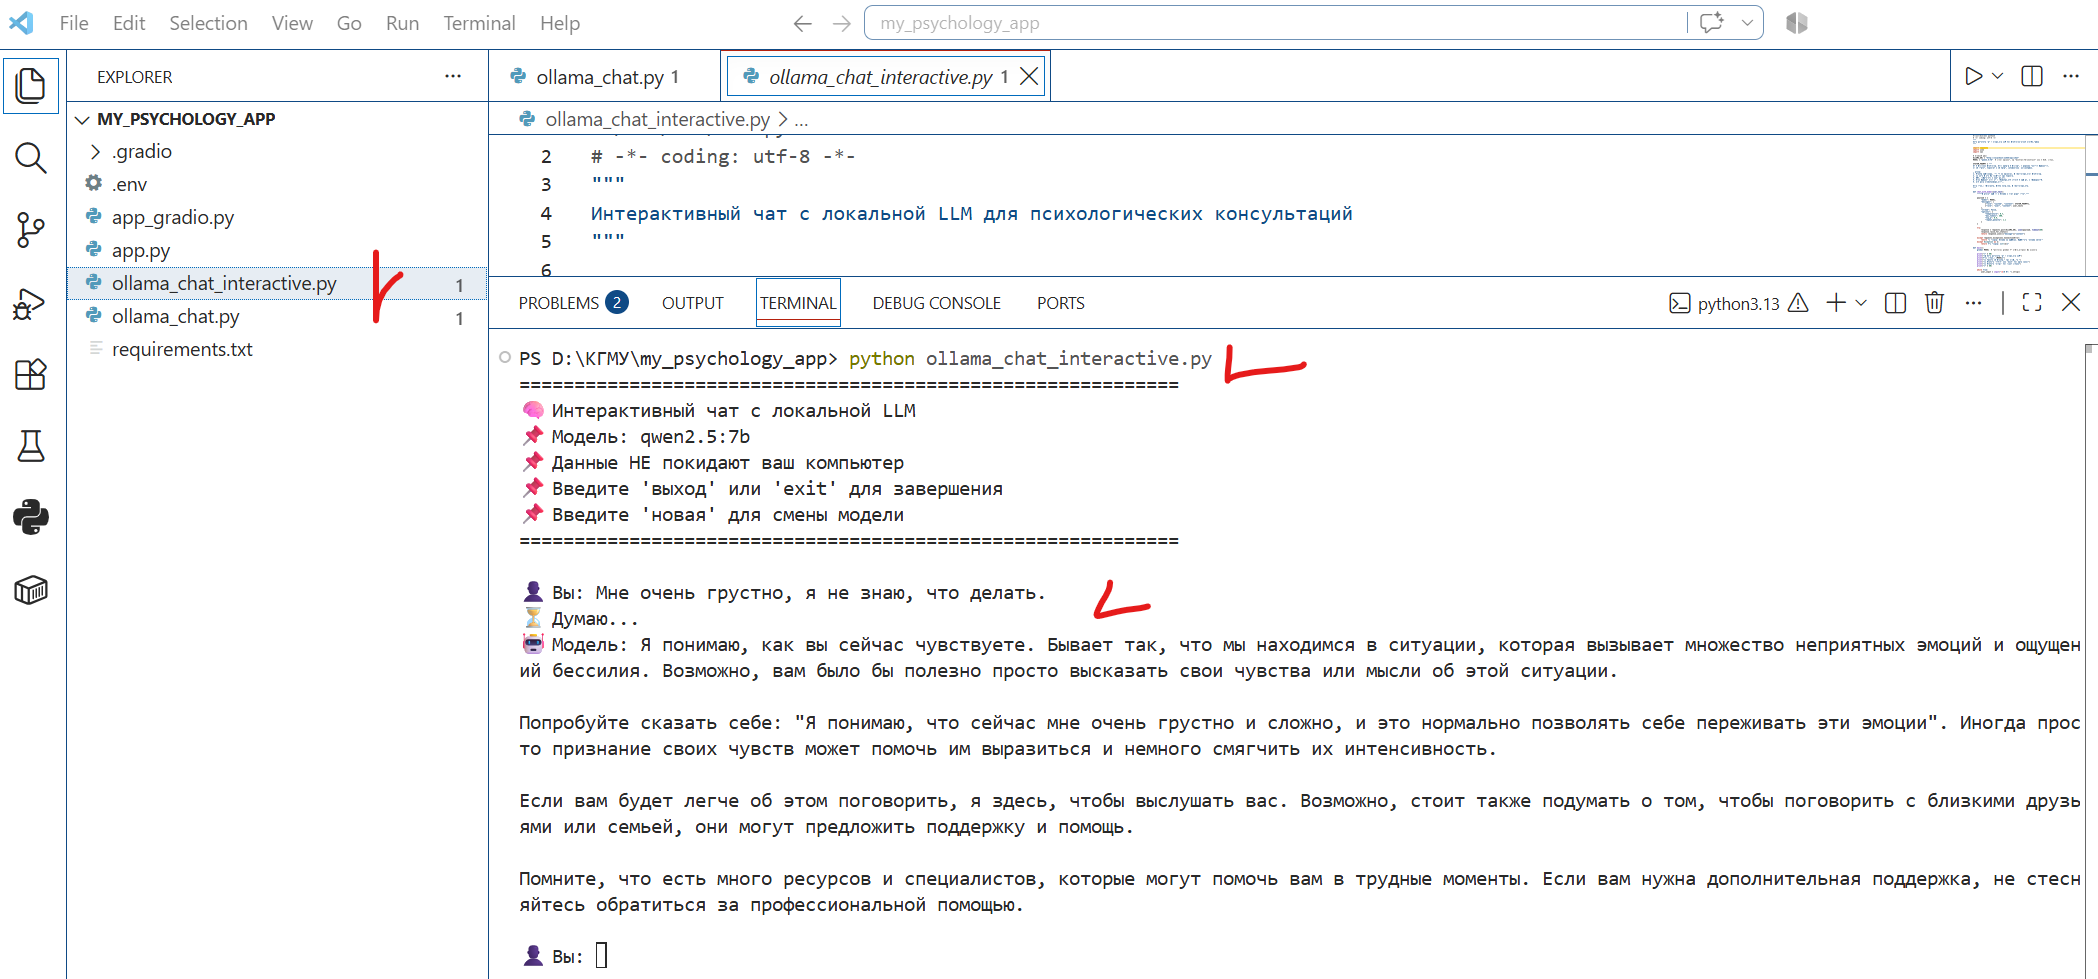

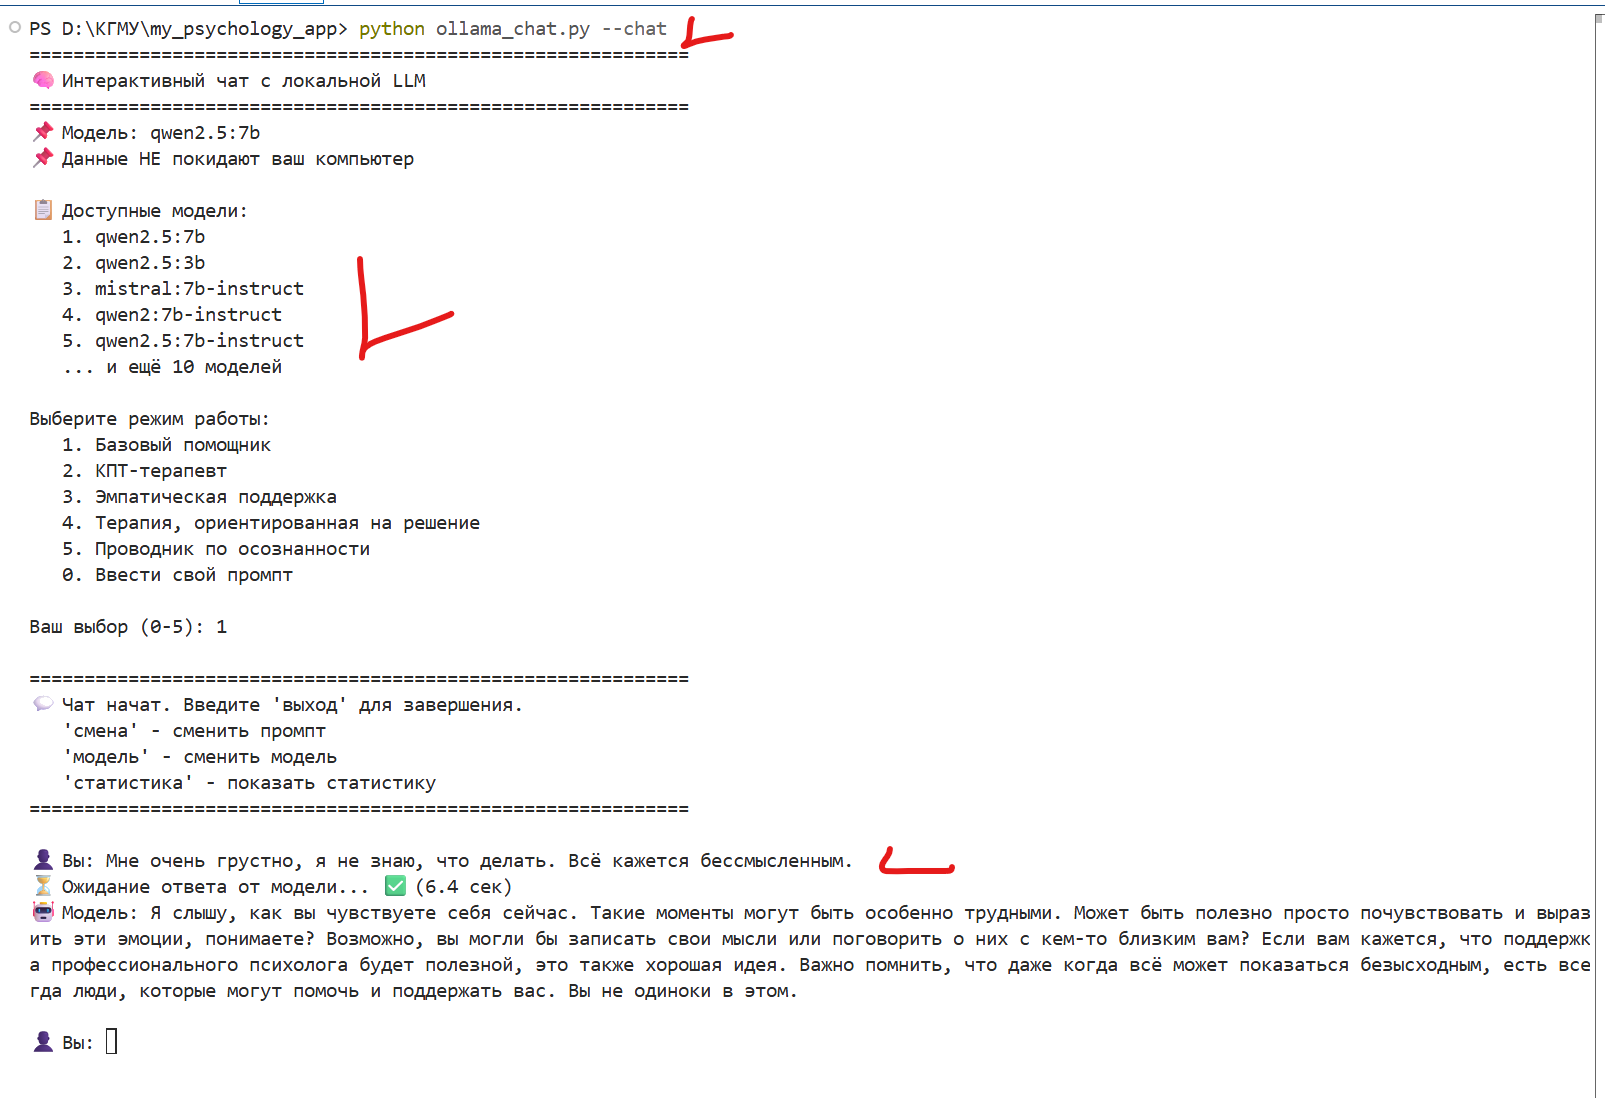



## 6.8. Таблица: сравнение системных промптов

| Промпт | Стиль | Основная задача | Кому подходит |
|--------|-------|-----------------|---------------|
| **Базовый** | Спокойный, профессиональный | Общий анализ текстов | Начинающие психологи |
| **КПТ** | Вопросы, анализ искажений | Работа с негативными мыслями | КПТ-терапевты |
| **Эмпатический** | Тёплый, поддерживающий | Эмоциональная поддержка | Коучинг, поддержка |
| **Профессиональный** | Структурированный, терапевтический | Подготовка к сессиям | Опытные психологи |

---

## 6.9. Основные выводы раздела

1. **Системный промпт** — это инструкция, которая задаёт модели роль, стиль и правила поведения на протяжении всего диалога.

2. **Правильно составленный промпт** — это вопрос безопасности. Он предотвращает нежелательные высказывания, диагнозы и рекомендации.

3. **Разные задачи требуют разных промптов.** Для общего анализа подходит базовый промпт, для КПТ — сократический, для поддержки — эмпатический.

4. **Системный промпт должен содержать:** чёткую роль, явные запреты, стиль общения, правила безопасности и дисклеймер.

5. **Слишком жёсткий промпт** ограничивает гибкость модели. Слишком свободный — может привести к нежелательным ответам.

6. **В коде системный промпт передаётся** в поле `messages` с ролью `system` через Ollama API.

7. **Этическая ответственность** за ответы модели лежит на психологе, а не на модели.

8. **Файл для кода** называется `ollama_chat.py`, запускается командой `python ollama_chat.py`.

9. **Для работы нужна библиотека `requests`**, которая устанавливается через `pip install requests` или из `requirements.txt`.

10. **Данные не покидают ваш компьютер** — всё работает локально через `localhost:11434`, что обеспечивает соответствие 152-ФЗ.




## 7. ЭТИЧЕСКИЕ РЕКОМЕНДАЦИИ ДЛЯ ПСИХОЛОГОВ

### 7.1. Что можно и нельзя делать

| ✅ МОЖНО | ❌ НЕЛЬЗЯ |
|----------|-----------|
| Использовать для анализа **анонимизированных** текстов | Загружать ФИО, адреса, телефоны |
| Использовать для подготовки к сессиям | Полагаться на модель в диагностике |
| Использовать для структурирования заметок | Использовать как замену супервизии |
| Использовать в исследовательских целях | Передавать данные модели без согласия пациента |
| Использовать локально (данные не покидают компьютер) | Использовать облачные аналоги с реальными данными |

### 7.2. Дисклеймер для пациентов

```
⚠️ Важно: этот чат-бот использует локальную ИИ-модель.
Ваши данные НЕ покидают ваш компьютер и НЕ передаются третьим лицам.

Тем не менее, помните:
• Это НЕ замена профессиональному психологу.
• Результаты НЕ являются диагнозом.
• При серьёзных проблемах обращайтесь к специалисту.

Если вы испытываете суицидальные мысли – немедленно обратитесь
в кризисный центр или позвоните по телефону доверия.
```

### 7.3. Чек-лист этичного использования




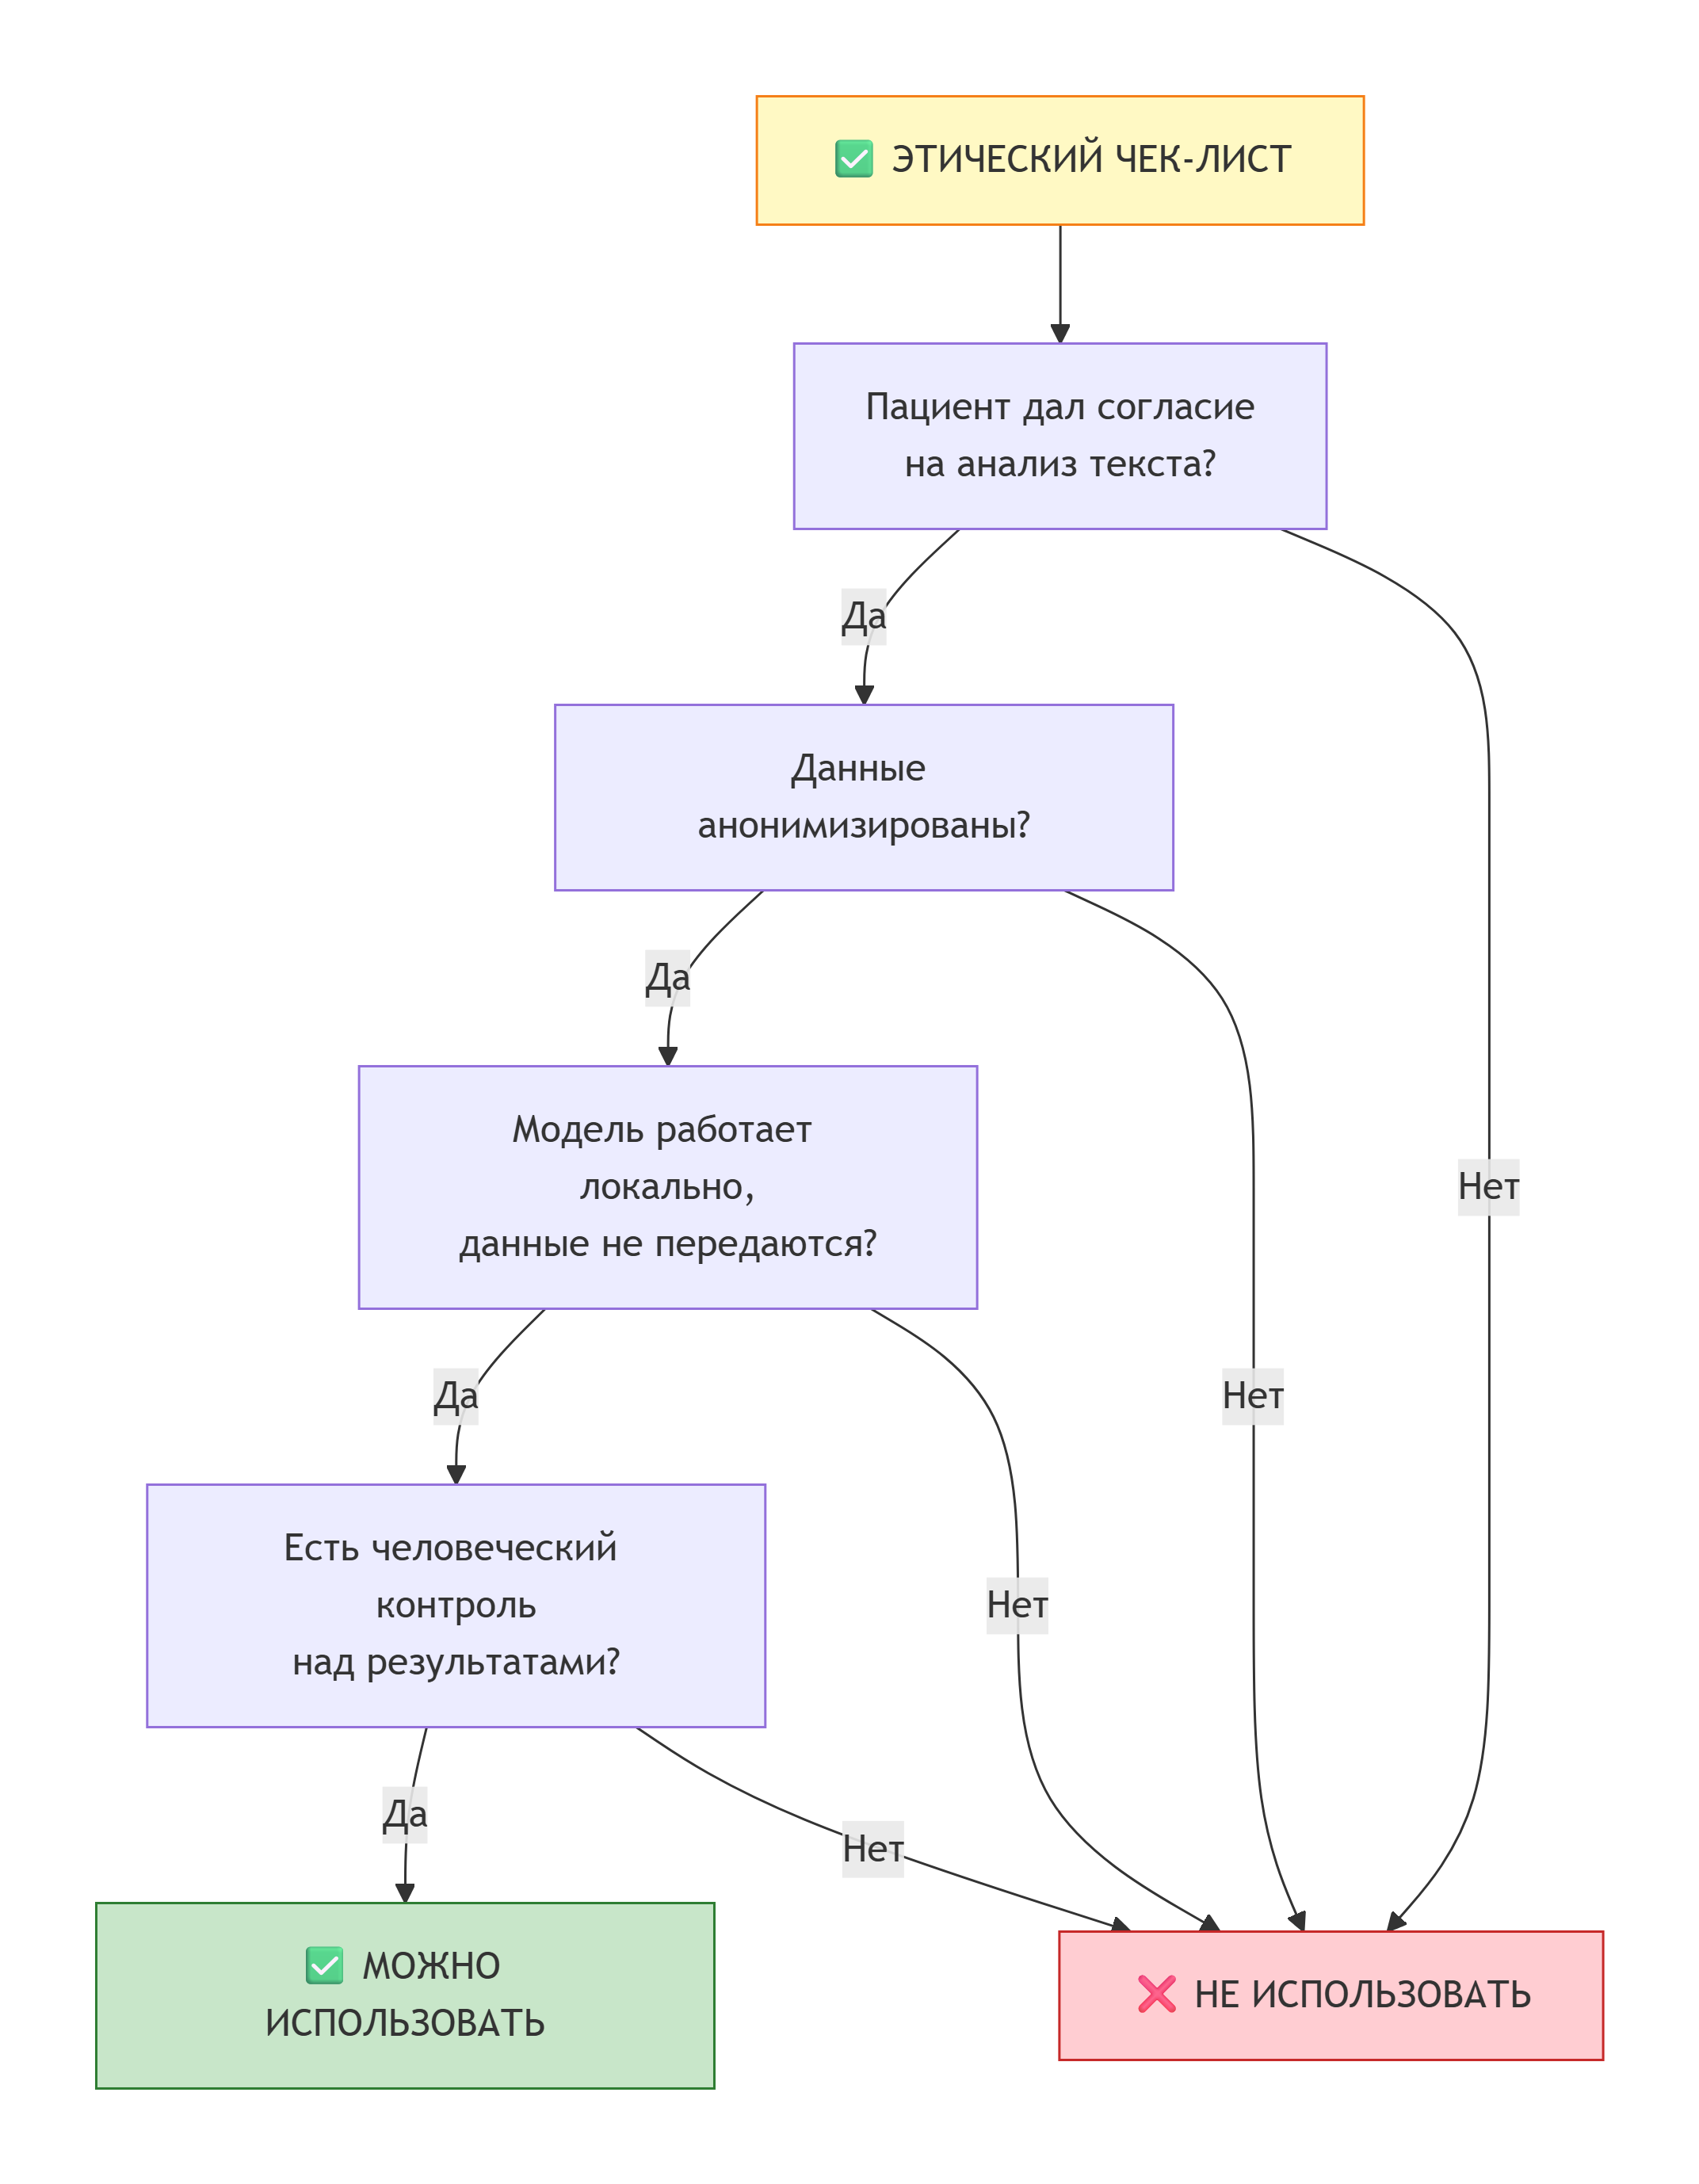



### 7.4. Практические рекомендации

| Ситуация | Рекомендация |
|----------|--------------|
| **Подготовка к сессии** | Можно использовать локальную LLM для структурирования заметок |
| **Анализ дневников** | Только после анонимизации данных |
| **Работа с пациентами** | Всегда с информированным согласием |
| **Исследования** | Только после одобрения этического комитета |
| **Супервизия** | Можно использовать для подготовки, но не для замены |

---

## 8. ЗАКЛЮЧЕНИЕ

### 8.1. Что мы сегодня узнали

| Что узнали | Ключевая идея |
|------------|---------------|
| **Преимущества локального запуска** | Данные не покидают компьютер, соответствие 152-ФЗ |
| **Ollama** | Платформа для запуска LLM локально |
| **VS Code + Ollama** | Работа с моделями прямо в редакторе |
| **Модели** | Qwen, DeepSeek, Llama, Mistral – сравнение и выбор |
| **Системные промпты** | Настройка роли и правил для психологического контекста |

### 8.2. Ключевая мысль

> Локальные LLM — это **единственный этически приемлемый способ** использования генеративного ИИ в клинической психологии. Они дают всю мощь современных моделей, но **сохраняют полный контроль над данными** пациентов. Это не компромисс — это **стандарт** для работы с чувствительной информацией.

**Связь с будущим:**

- В следующей лекции мы создадим **полноценное чат-приложение** для психологической поддержки на основе локальной LLM.
- Вы сможете использовать его в клинике, не опасаясь нарушений 152-ФЗ.

---

## 9. ВОПРОСЫ ДЛЯ САМОПРОВЕРКИ

1. Почему локальный запуск LLM важен для психолога? Какие преимущества он даёт?

2. Что такое Ollama и для чего он нужен?

3. Как установить Ollama на Windows/macOS/Linux?

4. Какие модели доступны в Ollama? Какую модель вы бы рекомендовали для работы с русскоязычными текстами и почему?

5. Как подключить Ollama к VS Code? Какие расширения для этого существуют?

6. Что такое системный промпт? Приведите пример для психологической консультации.

7. В чём разница между Qwen2.5:7B, DeepSeek-R1:7B и Llama3.2:8B? Какая модель лучше для работы с русским языком?

8. Какие этические требования нужно соблюдать при использовании локальных LLM в психологии?

9. Как 152-ФЗ связан с использованием ИИ в психологической практике?

10. **Рефлексивный вопрос:** готовы ли вы использовать локальную LLM в своей будущей практике? Какие риски вы видите и как их минимизировать?

---

## 10. ДОМАШНЕЕ ЗАДАНИЕ (срок — 2 недели)

**Часть 1. Установка и настройка (отчёт)**

Установите Ollama на свой компьютер:

1. Скачайте и установите Ollama.
2. Скачайте модель Qwen2.5:7B (или другую, если недостаточно ресурсов).
3. Установите расширение Ollama в VS Code.
4. Проверьте, что модель работает (отправьте тестовый запрос через терминал: `ollama run qwen2.5:7b "Привет, как дела?"`).

**Что сдать:** скриншоты каждого шага + краткое описание (1–2 стр.).

---

**Часть 2. Тестирование системных промптов (1–2 страницы)**

Возьмите один из системных промптов из лекции (или создайте свой) и протестируйте его в Ollama.

**Что сделать:**

1. Запустите модель с системным промптом (через API или терминал).
2. Задайте 3–4 вопроса от имени пациента (например: «Мне очень грустно, я не знаю, что делать»).
3. Запишите ответы модели.
4. Напишите рефлексию: соответствует ли ответ модели заданной роли? Что можно улучшить в промпте?

**Что сдать:** текст промпта, вопросы, ответы модели, рефлексия (1–2 стр.).

---

**Часть 3. Рефлексия об этике (1–2 страницы)**

Напишите эссе на тему:

*«Локальные LLM в психологии: возможности и этические границы»*

Включите:

- Какие возможности открывают локальные модели для психолога?
- Какие этические риски вы видите?
- Как вы будете объяснять пациенту использование ИИ в работе?
- Где проходит граница между «помощником» и «заменой» психолога?

---

## 11. ЛИТЕРАТУРА

1. Ollama Official Documentation (2024). *Getting Started with Ollama*. https://docs.ollama.com
2. Федеральный закон № 152-ФЗ «О персональных данных» (2006).
3. RefalMachine/ruadapt_qwen2.5_7B_ext_u48_instruct. *Адаптированная на русский язык модель Qwen2.5-7B*. Hugging Face.
4. DeepSeek-R1 Hardware Guide (2026). *Optimal GPU, VRAM, and RAM configurations*. GitHub.
5. General Compute (2026). *The 7-8B Battle: Llama 3.1 8B vs Mistral 7B v0.3 vs Qwen 2.5 7B*.
6. Системные промпты для психологических консультаций. Hugging Face: marcgreen/therapeutic-qwen3-14b, UKPLab/Llama3-MAGneT, build-small-hackathon/reframe.
7. Российский журнал цифровой психологии. (2025). *Применение локальных LLM в клинической практике*. Том 12, № 4, 56–67.
